In [4]:
import pandas as pd

In [5]:
data=pd.read_csv(r"csv.csv")

In [7]:
!pip install --upgrade scikit-learn

In [8]:
import matplotlib.pylab as plt
from matplotlib import pyplot
import pandas as pd
import numpy as np
import seaborn as sns
import random
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix
from  xgboost import XGBClassifier
from sklearn.neural_network import MLPClassifier
from imblearn.over_sampling import SMOTE
from sklearn.utils import resample
from scipy import stats
from sklearn import metrics
from catboost import CatBoostClassifier
from sklearn.tree import DecisionTreeClassifier 
from sklearn.neighbors import KNeighborsClassifier
from sklearn.preprocessing import LabelEncoder
from sklearn.ensemble import RandomForestClassifier
from sklearn.ensemble import ExtraTreesClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.svm import SVC, LinearSVC
import lightgbm as lgb
%matplotlib inline
pyplot.rcParams.update({'figure.figsize': (8.0, 8.0)})
pyplot.rcParams.update({'font.size': 14})
pyplot.rcParams.update({'figure.dpi': 300})

from xgboost import XGBClassifier
from catboost import CatBoostClassifier


In [9]:
data.head()

,age,sex,on_thyroxine,query_on_thyroxine,on_antithyroid_medication,sick,pregnant,thyroid_surgery,I131_treatment,query_hypothyroid,...,TT4_measured,TT4,T4U_measured,T4U,FTI_measured,FTI,TBG_measured,TBG,referral_source,Class
0,41,F,f,f,f,f,f,f,f,f,...,t,125,t,1.14,t,109,f,?,SVHC,negative
1,23,F,f,f,f,f,f,f,f,f,...,t,102,f,?,f,?,f,?,other,negative
2,46,M,f,f,f,f,f,f,f,f,...,t,109,t,0.91,t,120,f,?,other,negative
3,70,F,t,f,f,f,f,f,f,f,...,t,175,f,?,f,?,f,?,other,negative
4,70,F,f,f,f,f,f,f,f,f,...,t,61,t,0.87,t,70,f,?,SVI,negative


In [10]:
display(data.head(10))

,age,sex,on_thyroxine,query_on_thyroxine,on_antithyroid_medication,sick,pregnant,thyroid_surgery,I131_treatment,query_hypothyroid,...,TT4_measured,TT4,T4U_measured,T4U,FTI_measured,FTI,TBG_measured,TBG,referral_source,Class
0,41,F,f,f,f,f,f,f,f,f,...,t,125,t,1.14,t,109,f,?,SVHC,negative
1,23,F,f,f,f,f,f,f,f,f,...,t,102,f,?,f,?,f,?,other,negative
2,46,M,f,f,f,f,f,f,f,f,...,t,109,t,0.91,t,120,f,?,other,negative
3,70,F,t,f,f,f,f,f,f,f,...,t,175,f,?,f,?,f,?,other,negative
4,70,F,f,f,f,f,f,f,f,f,...,t,61,t,0.87,t,70,f,?,SVI,negative
5,18,F,t,f,f,f,f,f,f,f,...,t,183,t,1.3,t,141,f,?,other,negative
6,59,F,f,f,f,f,f,f,f,f,...,t,72,t,0.92,t,78,f,?,other,negative
7,80,F,f,f,f,f,f,f,f,f,...,t,80,t,0.7,t,115,f,?,SVI,negative
8,66,F,f,f,f,f,f,f,f,f,...,t,123,t,0.93,t,132,f,?,SVI,negative
9,68,M,f,f,f,f,f,f,f,f,...,t,83,t,0.89,t,93,f,?,SVI,negative


In [11]:
data.tail()

,age,sex,on_thyroxine,query_on_thyroxine,on_antithyroid_medication,sick,pregnant,thyroid_surgery,I131_treatment,query_hypothyroid,...,TT4_measured,TT4,T4U_measured,T4U,FTI_measured,FTI,TBG_measured,TBG,referral_source,Class
3767,30,F,f,f,f,f,f,f,f,f,...,f,?,f,?,f,?,f,?,other,negative
3768,68,F,f,f,f,f,f,f,f,f,...,t,124,t,1.08,t,114,f,?,SVI,negative
3769,74,F,f,f,f,f,f,f,f,f,...,t,112,t,1.07,t,105,f,?,other,negative
3770,72,M,f,f,f,f,f,f,f,f,...,t,82,t,0.94,t,87,f,?,SVI,negative
3771,64,F,f,f,f,f,f,f,f,f,...,t,99,t,1.07,t,92,f,?,other,negative


In [12]:
display(data.dtypes)

age                          object
sex                          object
on_thyroxine                 object
query_on_thyroxine           object
on_antithyroid_medication    object
sick                         object
pregnant                     object
thyroid_surgery              object
I131_treatment               object
query_hypothyroid            object
query_hyperthyroid           object
lithium                      object
goitre                       object
tumor                        object
hypopituitary                object
psych                        object
TSH_measured                 object
TSH                          object
T3_measured                  object
T3                           object
TT4_measured                 object
TT4                          object
T4U_measured                 object
T4U                          object
FTI_measured                 object
FTI                          object
TBG_measured                 object
TBG                         

In [13]:
data = data.rename(columns={"Class": "sclass"})

In [14]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3772 entries, 0 to 3771
Data columns (total 30 columns):
 #   Column                     Non-Null Count  Dtype 
---  ------                     --------------  ----- 
 0   age                        3772 non-null   object
 1   sex                        3772 non-null   object
 2   on_thyroxine               3772 non-null   object
 3   query_on_thyroxine         3772 non-null   object
 4   on_antithyroid_medication  3772 non-null   object
 5   sick                       3772 non-null   object
 6   pregnant                   3772 non-null   object
 7   thyroid_surgery            3772 non-null   object
 8   I131_treatment             3772 non-null   object
 9   query_hypothyroid          3772 non-null   object
 10  query_hyperthyroid         3772 non-null   object
 11  lithium                    3772 non-null   object
 12  goitre                     3772 non-null   object
 13  tumor                      3772 non-null   object
 14  hypopitu

In [15]:
print(data.columns)

Index(['age', 'sex', 'on_thyroxine', 'query_on_thyroxine',
       'on_antithyroid_medication', 'sick', 'pregnant', 'thyroid_surgery',
       'I131_treatment', 'query_hypothyroid', 'query_hyperthyroid', 'lithium',
       'goitre', 'tumor', 'hypopituitary', 'psych', 'TSH_measured', 'TSH',
       'T3_measured', 'T3', 'TT4_measured', 'TT4', 'T4U_measured', 'T4U',
       'FTI_measured', 'FTI', 'TBG_measured', 'TBG', 'referral_source',
       'sclass'],
      dtype='object')


In [16]:
data['sex'] = data['sex'].map({'F': 1, 'M': 0})

In [17]:
display(data.shape)
display(data.head(10))
display(data.dtypes)

(3772, 30)

,age,sex,on_thyroxine,query_on_thyroxine,on_antithyroid_medication,sick,pregnant,thyroid_surgery,I131_treatment,query_hypothyroid,...,TT4_measured,TT4,T4U_measured,T4U,FTI_measured,FTI,TBG_measured,TBG,referral_source,sclass
0,41,1.0,f,f,f,f,f,f,f,f,...,t,125,t,1.14,t,109,f,?,SVHC,negative
1,23,1.0,f,f,f,f,f,f,f,f,...,t,102,f,?,f,?,f,?,other,negative
2,46,0.0,f,f,f,f,f,f,f,f,...,t,109,t,0.91,t,120,f,?,other,negative
3,70,1.0,t,f,f,f,f,f,f,f,...,t,175,f,?,f,?,f,?,other,negative
4,70,1.0,f,f,f,f,f,f,f,f,...,t,61,t,0.87,t,70,f,?,SVI,negative
5,18,1.0,t,f,f,f,f,f,f,f,...,t,183,t,1.3,t,141,f,?,other,negative
6,59,1.0,f,f,f,f,f,f,f,f,...,t,72,t,0.92,t,78,f,?,other,negative
7,80,1.0,f,f,f,f,f,f,f,f,...,t,80,t,0.7,t,115,f,?,SVI,negative
8,66,1.0,f,f,f,f,f,f,f,f,...,t,123,t,0.93,t,132,f,?,SVI,negative
9,68,0.0,f,f,f,f,f,f,f,f,...,t,83,t,0.89,t,93,f,?,SVI,negative


age                           object
sex                          float64
on_thyroxine                  object
query_on_thyroxine            object
on_antithyroid_medication     object
sick                          object
pregnant                      object
thyroid_surgery               object
I131_treatment                object
query_hypothyroid             object
query_hyperthyroid            object
lithium                       object
goitre                        object
tumor                         object
hypopituitary                 object
psych                         object
TSH_measured                  object
TSH                           object
T3_measured                   object
T3                            object
TT4_measured                  object
TT4                           object
T4U_measured                  object
T4U                           object
FTI_measured                  object
FTI                           object
TBG_measured                  object
T

In [18]:
display(data.shape)

(3772, 30)

In [19]:
print("Sick-euthyroid:")
sex_series2 = pd.Series(data[data.columns[1]].values)
display(sex_series2.value_counts())


Sick-euthyroid:


1.0    2480
0.0    1142
Name: count, dtype: int64

In [20]:
#data pre processing observing the set of possible values for each attribute
for column in data.columns:
    listOfValues=set(data[column])
    print(column,": ",listOfValues)

age :  {'18', '80', '42', '94', '86', '84', '17', '58', '12', '30', '11', '48', '52', '46', '63', '67', '32', '60', '49', '53', '33', '55', '14', '61', '82', '26', '65', '74', '36', '21', '79', '83', '68', '90', '92', '70', '73', '87', '77', '64', '76', '81', '66', '7', '2', '23', '56', '29', '8', '91', '72', '78', '40', '57', '47', '41', '35', '39', '89', '38', '4', '?', '34', '10', '45', '455', '69', '16', '43', '31', '44', '24', '54', '71', '22', '85', '59', '37', '62', '13', '50', '20', '88', '6', '93', '25', '51', '75', '1', '19', '27', '5', '15', '28'}
sex :  {0.0, 1.0, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, na

In [23]:
# Replace all "?" (even if there are spaces) with NaN
data = data.replace("?", np.nan).replace(" ?", np.nan)

# Now check missing values
print(data.isna().sum())

age                             1
sex                           150
on_thyroxine                    0
query_on_thyroxine              0
on_antithyroid_medication       0
sick                            0
pregnant                        0
thyroid_surgery                 0
I131_treatment                  0
query_hypothyroid               0
query_hyperthyroid              0
lithium                         0
goitre                          0
tumor                           0
hypopituitary                   0
psych                           0
TSH_measured                    0
TSH                           369
T3_measured                     0
T3                            769
TT4_measured                    0
TT4                           231
T4U_measured                    0
T4U                           387
FTI_measured                    0
FTI                           385
TBG_measured                    0
TBG                          3772
referral_source                 0
sclass        

In [24]:
del data['TBG']

In [26]:
import pandas as pd

data = pd.read_csv(r"csv.csv")

# Convert age column to numeric
data['age'] = pd.to_numeric(data['age'], errors='coerce')

# Fill missing values with median
data['age'] = data['age'].fillna(data['age'].median())

In [27]:
# Fill only numeric columns with their mean
data.fillna(data.mean(numeric_only=True), inplace=True)

# Check remaining missing values
print(data.isna().sum())

age                          0
sex                          0
on_thyroxine                 0
query_on_thyroxine           0
on_antithyroid_medication    0
sick                         0
pregnant                     0
thyroid_surgery              0
I131_treatment               0
query_hypothyroid            0
query_hyperthyroid           0
lithium                      0
goitre                       0
tumor                        0
hypopituitary                0
psych                        0
TSH_measured                 0
TSH                          0
T3_measured                  0
T3                           0
TT4_measured                 0
TT4                          0
T4U_measured                 0
T4U                          0
FTI_measured                 0
FTI                          0
TBG_measured                 0
TBG                          0
referral_source              0
Class                        0
dtype: int64


In [28]:
print(data['age'].unique()[:50])   # show first 50 unique values


[41. 23. 46. 70. 18. 59. 80. 66. 68. 84. 67. 71. 28. 65. 42. 63. 51. 81.
 54. 55. 60. 25. 73. 34. 78. 37. 85. 26. 58. 64. 44. 48. 61. 35. 83. 21.
 87. 53. 77. 27. 69. 74. 38. 76. 45. 36. 22. 43. 72. 82.]


In [29]:
print(data['Class'].value_counts())


Class
negative                   3481
compensated_hypothyroid     194
primary_hypothyroid          95
secondary_hypothyroid         2
Name: count, dtype: int64


In [32]:
# Replace t/f with 1/0 for all columns
data.replace({'t': 1, 'f': 0}, inplace=True)

In [33]:
from sklearn.preprocessing import LabelEncoder

categorical_cols = ['sex', 'on_thyroxine', 'query_on_thyroxine', 'on_antithyroid_medication',
                    'sick', 'pregnant', 'thyroid_surgery', 'I131_treatment',
                    'query_hypothyroid', 'query_hyperthyroid', 'lithium', 'goitre',
                    'tumor', 'hypopituitary', 'psych', 'referral_source']

le = LabelEncoder()
for col in categorical_cols:
    data[col] = le.fit_transform(data[col].astype(str))


In [34]:
data['Class'] = le.fit_transform(data['Class'].astype(str))


In [36]:
ax = sns.catplot(y="Class", kind="count", data=data, height=2.6, aspect=2.5)

C:\Users\iamya\AppData\Local\Temp\ipykernel_21564\1501533505.py:12: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_yticklabels(['{:,.0%}'.format(y) for y in ax.get_yticks()])


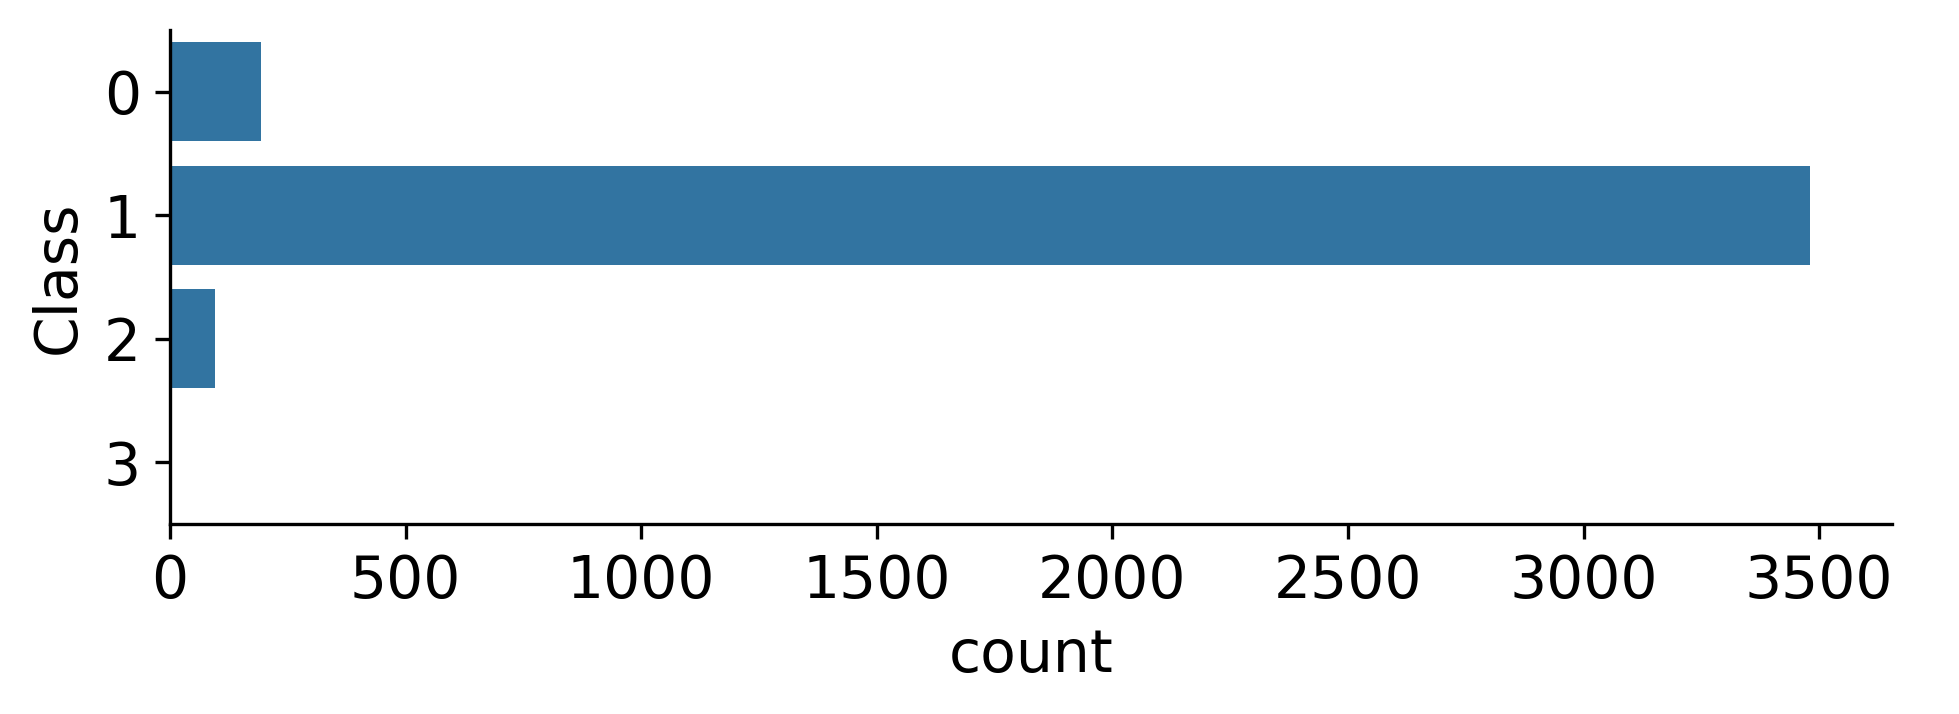

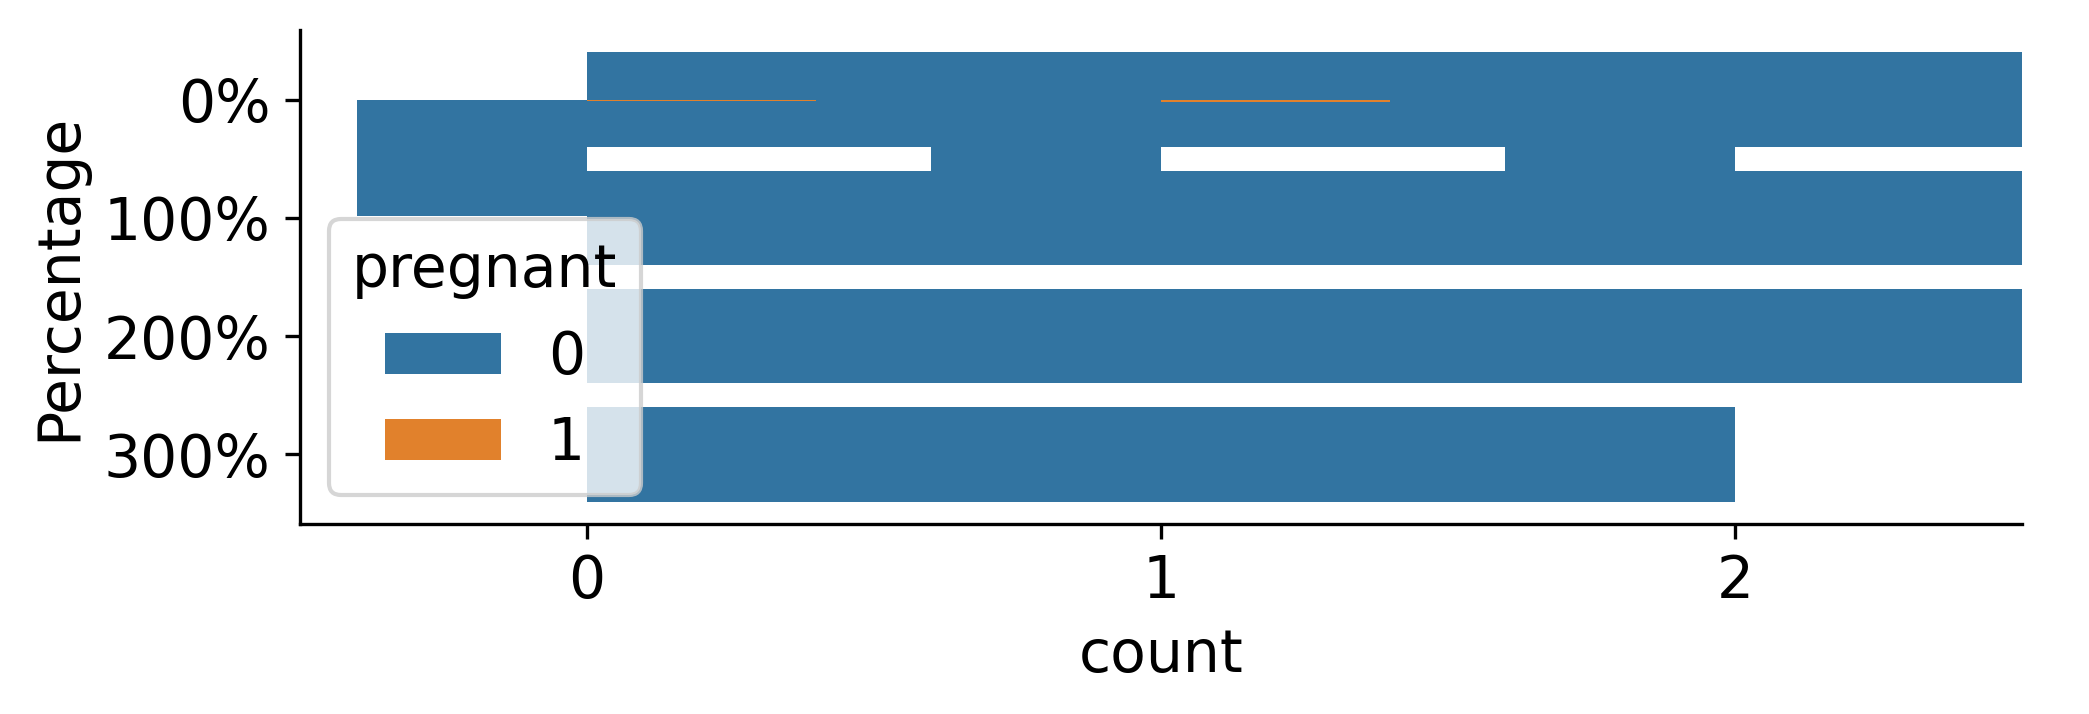

In [37]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

def barplot_percentages(feature):
    # calculate percentages
    g = data.groupby(feature)["pregnant"].value_counts(normalize=True).reset_index(name="percent")

    # plot
    ax = sns.barplot(x=feature, y="percent", hue="pregnant", data=g)
    ax.set_ylabel("Percentage")
    ax.set_yticklabels(['{:,.0%}'.format(y) for y in ax.get_yticks()])
    plt.show()

# Example use
barplot_percentages("sex")


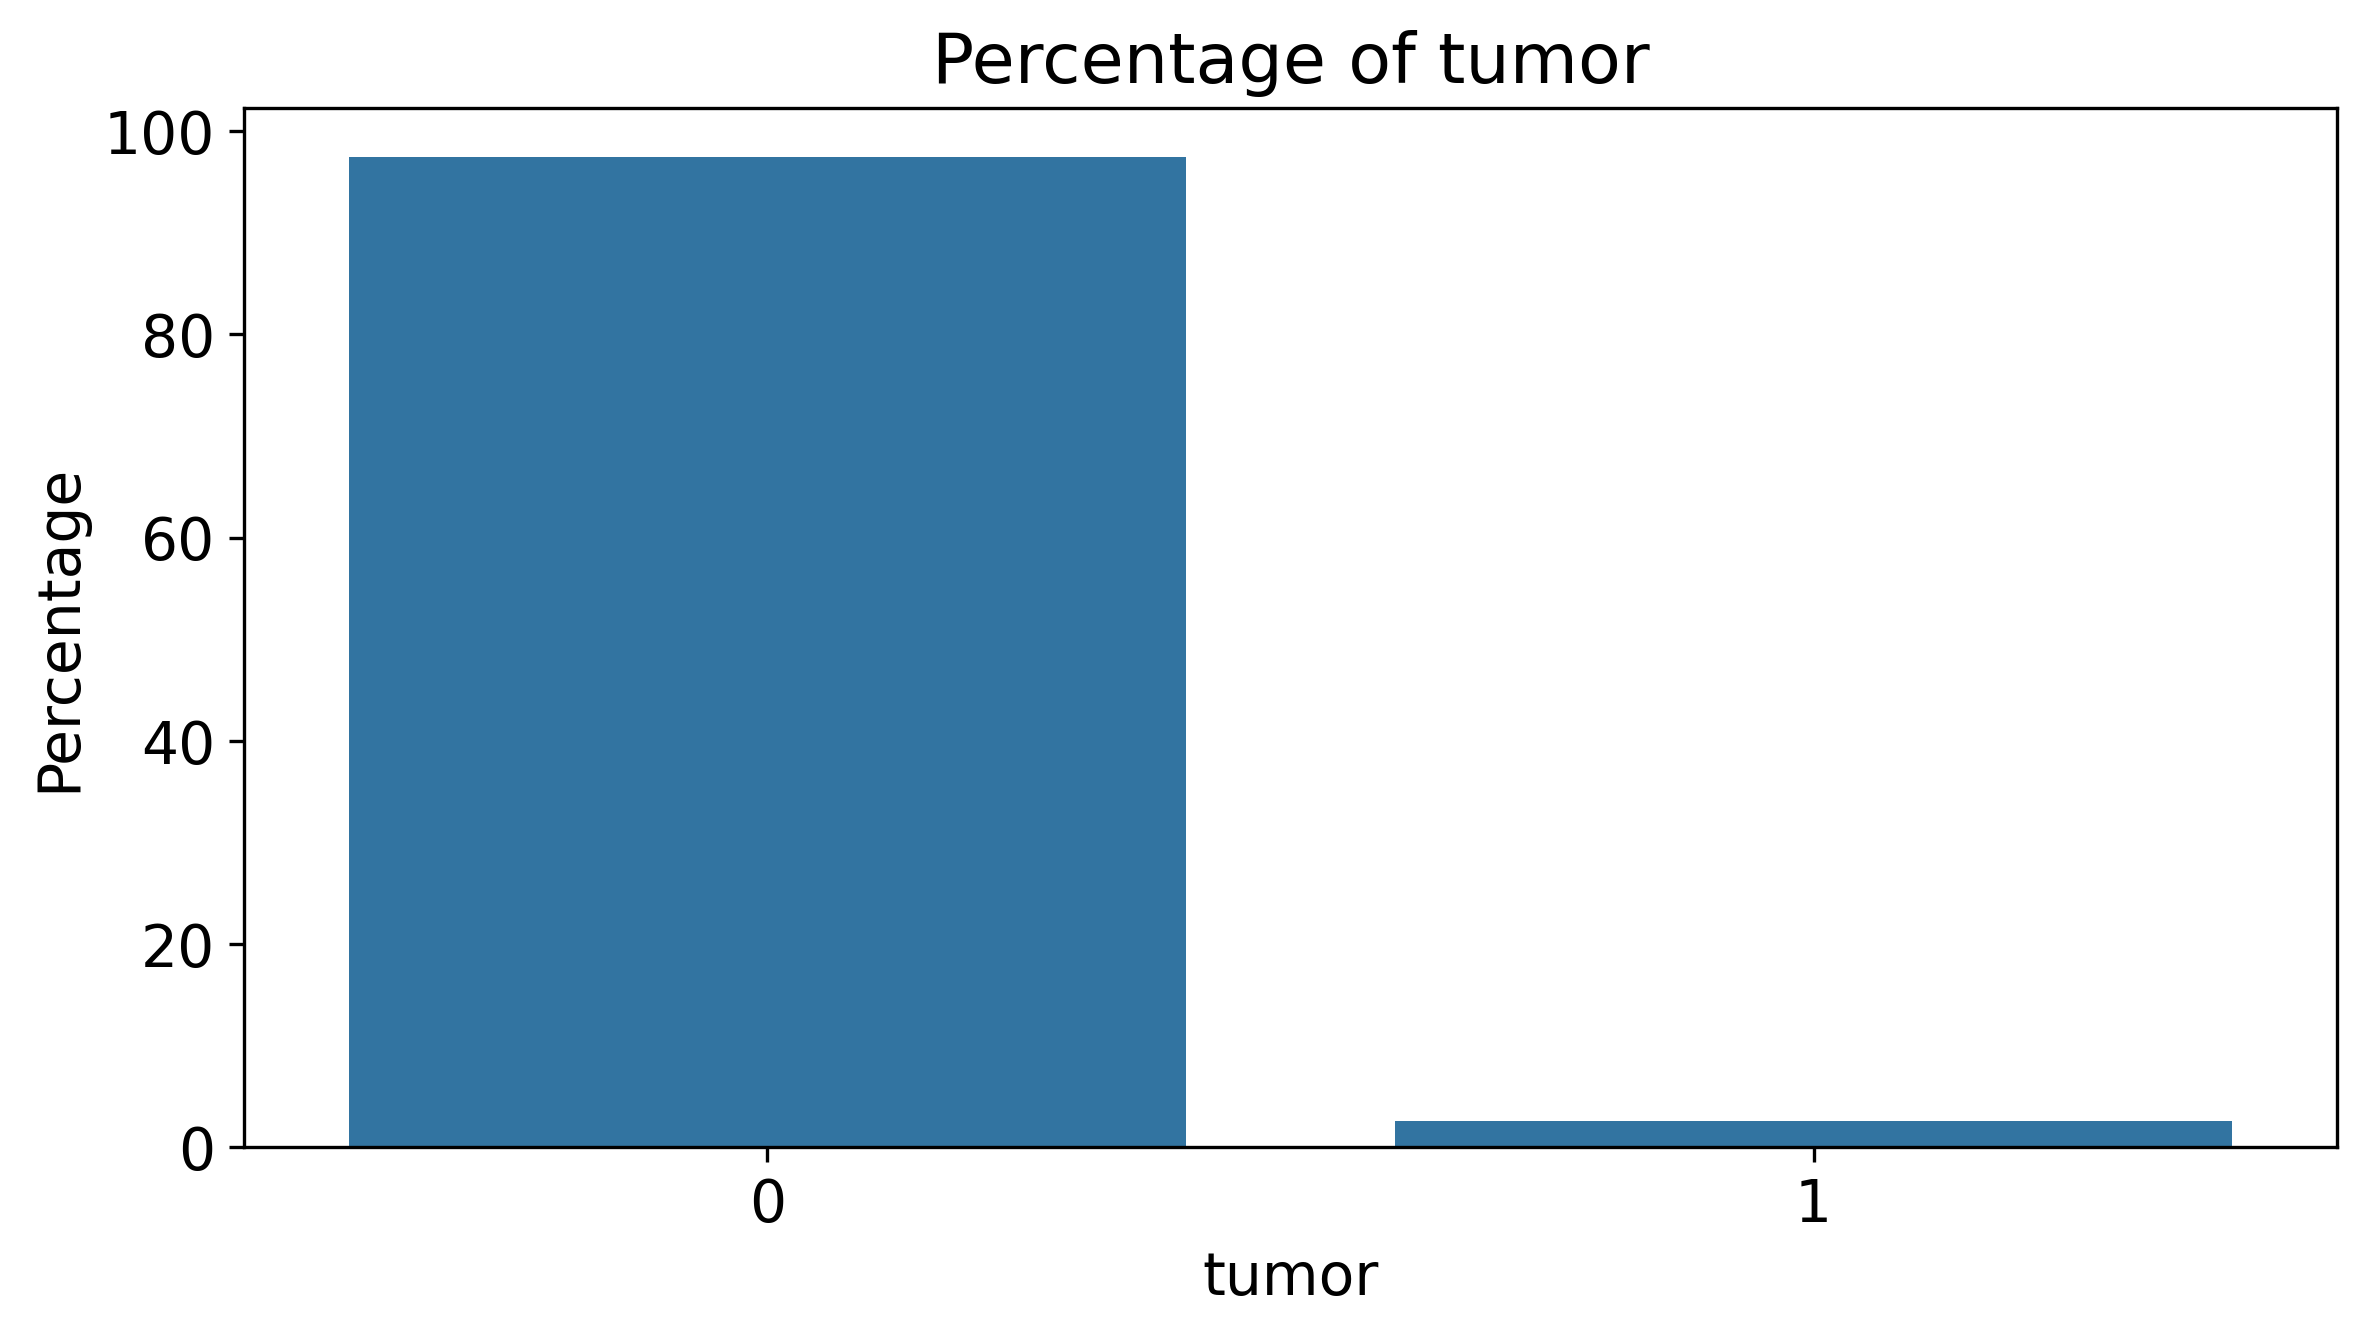

In [38]:
import matplotlib.pyplot as plt
import seaborn as sns

def barplot_percentages(column):
    counts = data[column].value_counts(normalize=True) * 100
    sns.barplot(x=counts.index, y=counts.values)
    plt.ylabel("Percentage")
    plt.xlabel(column)
    plt.title(f"Percentage of {column}")
    plt.show()

plt.figure(figsize=(9, 4.5))
barplot_percentages("tumor")

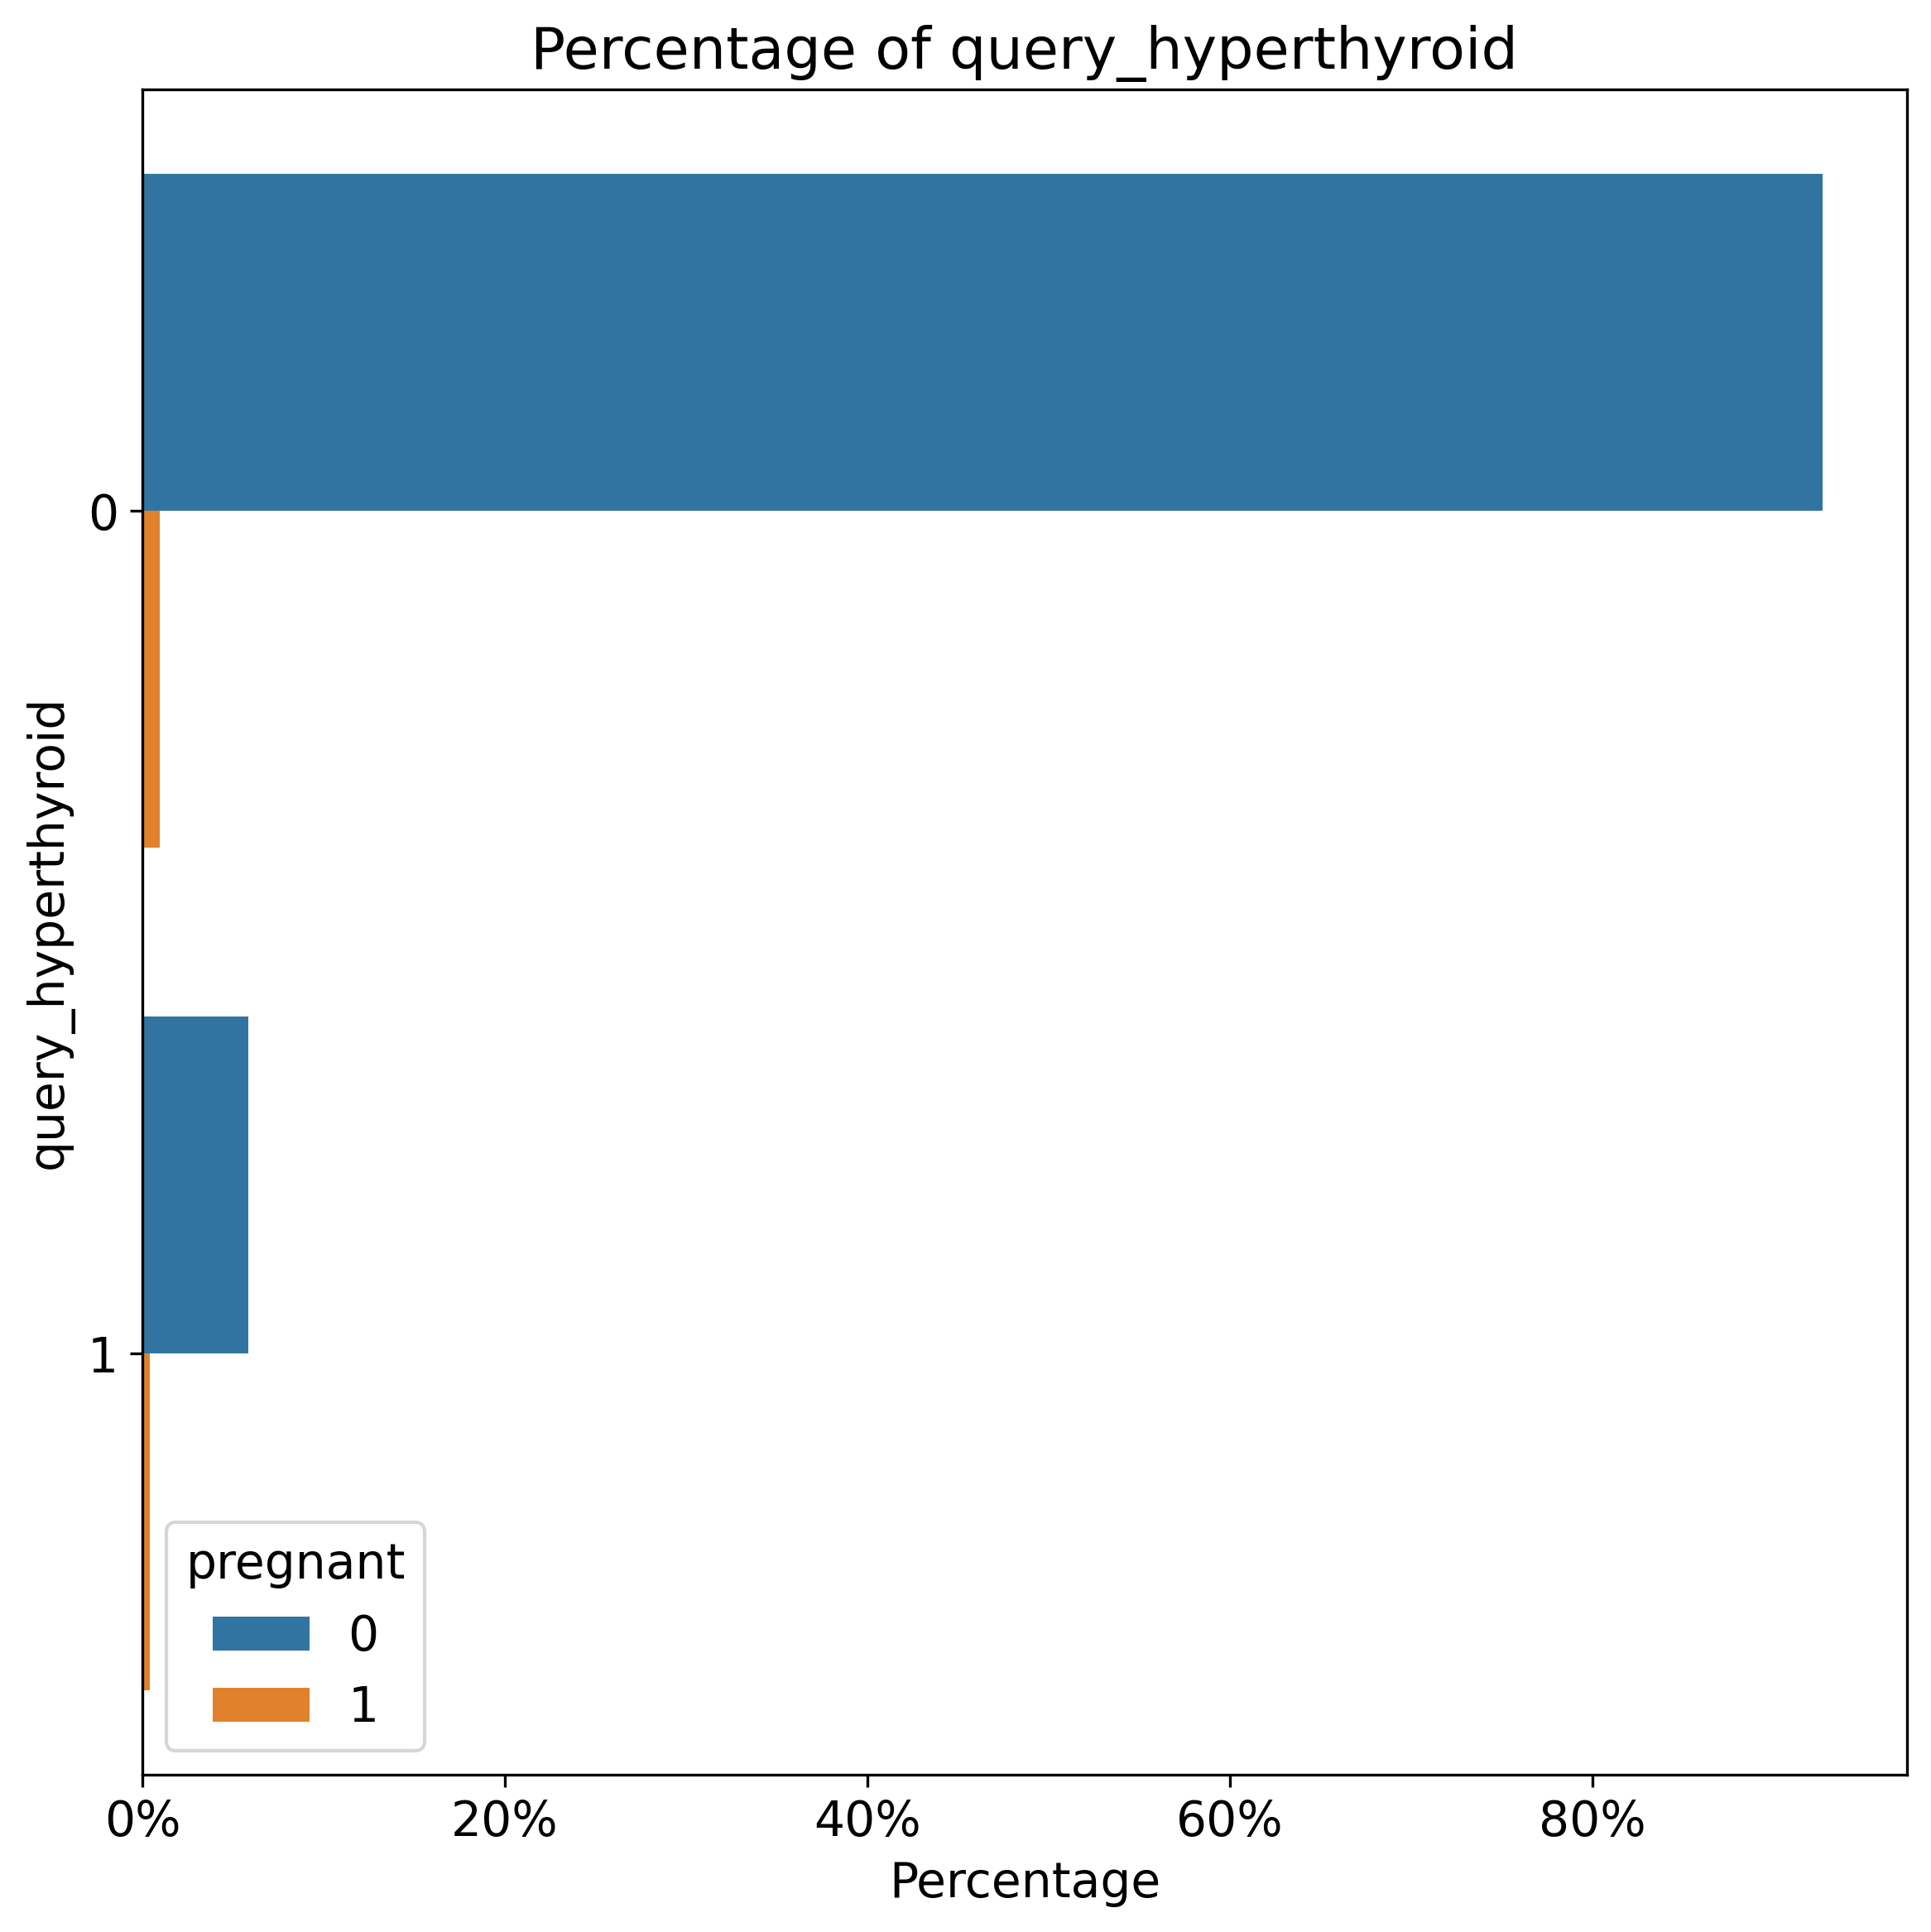

In [39]:
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd
from matplotlib.ticker import PercentFormatter

# Ensure data is a DataFrame (uncomment and edit if needed)
# data = pd.read_csv("your_file.csv")

# Rename categories for query_hyperthyroid if present
if "query_hyperthyroid" in data.columns:
    data["query_hyperthyroid"] = data["query_hyperthyroid"].replace({
        "f": "Negative",
        "t": "Sick Euthyroid"
    })

def barplot_percentages(feature, orient='v', axis_name="Percentage"):
    # Group and count pregnant values by feature
    g = data.groupby(feature)["pregnant"].value_counts().to_frame(name=axis_name).reset_index()
    
    # Calculate percentage of total dataset
    g[axis_name] = g[axis_name] / len(data)
    
    # Plot
    if orient == 'v':
        ax = sns.barplot(x=feature, y=axis_name, hue='pregnant', data=g, orient=orient)
        ax.yaxis.set_major_formatter(PercentFormatter(1))
        ax.set_ylabel(axis_name)
    else:
        ax = sns.barplot(x=axis_name, y=feature, hue='pregnant', data=g, orient=orient)
        ax.xaxis.set_major_formatter(PercentFormatter(1))
        ax.set_xlabel(axis_name)
    
    plt.title(f"Percentage of {feature}")
    plt.tight_layout()
    plt.show()

# Example call (edit feature name if needed)
barplot_percentages("query_hyperthyroid", orient='h', axis_name="Percentage")


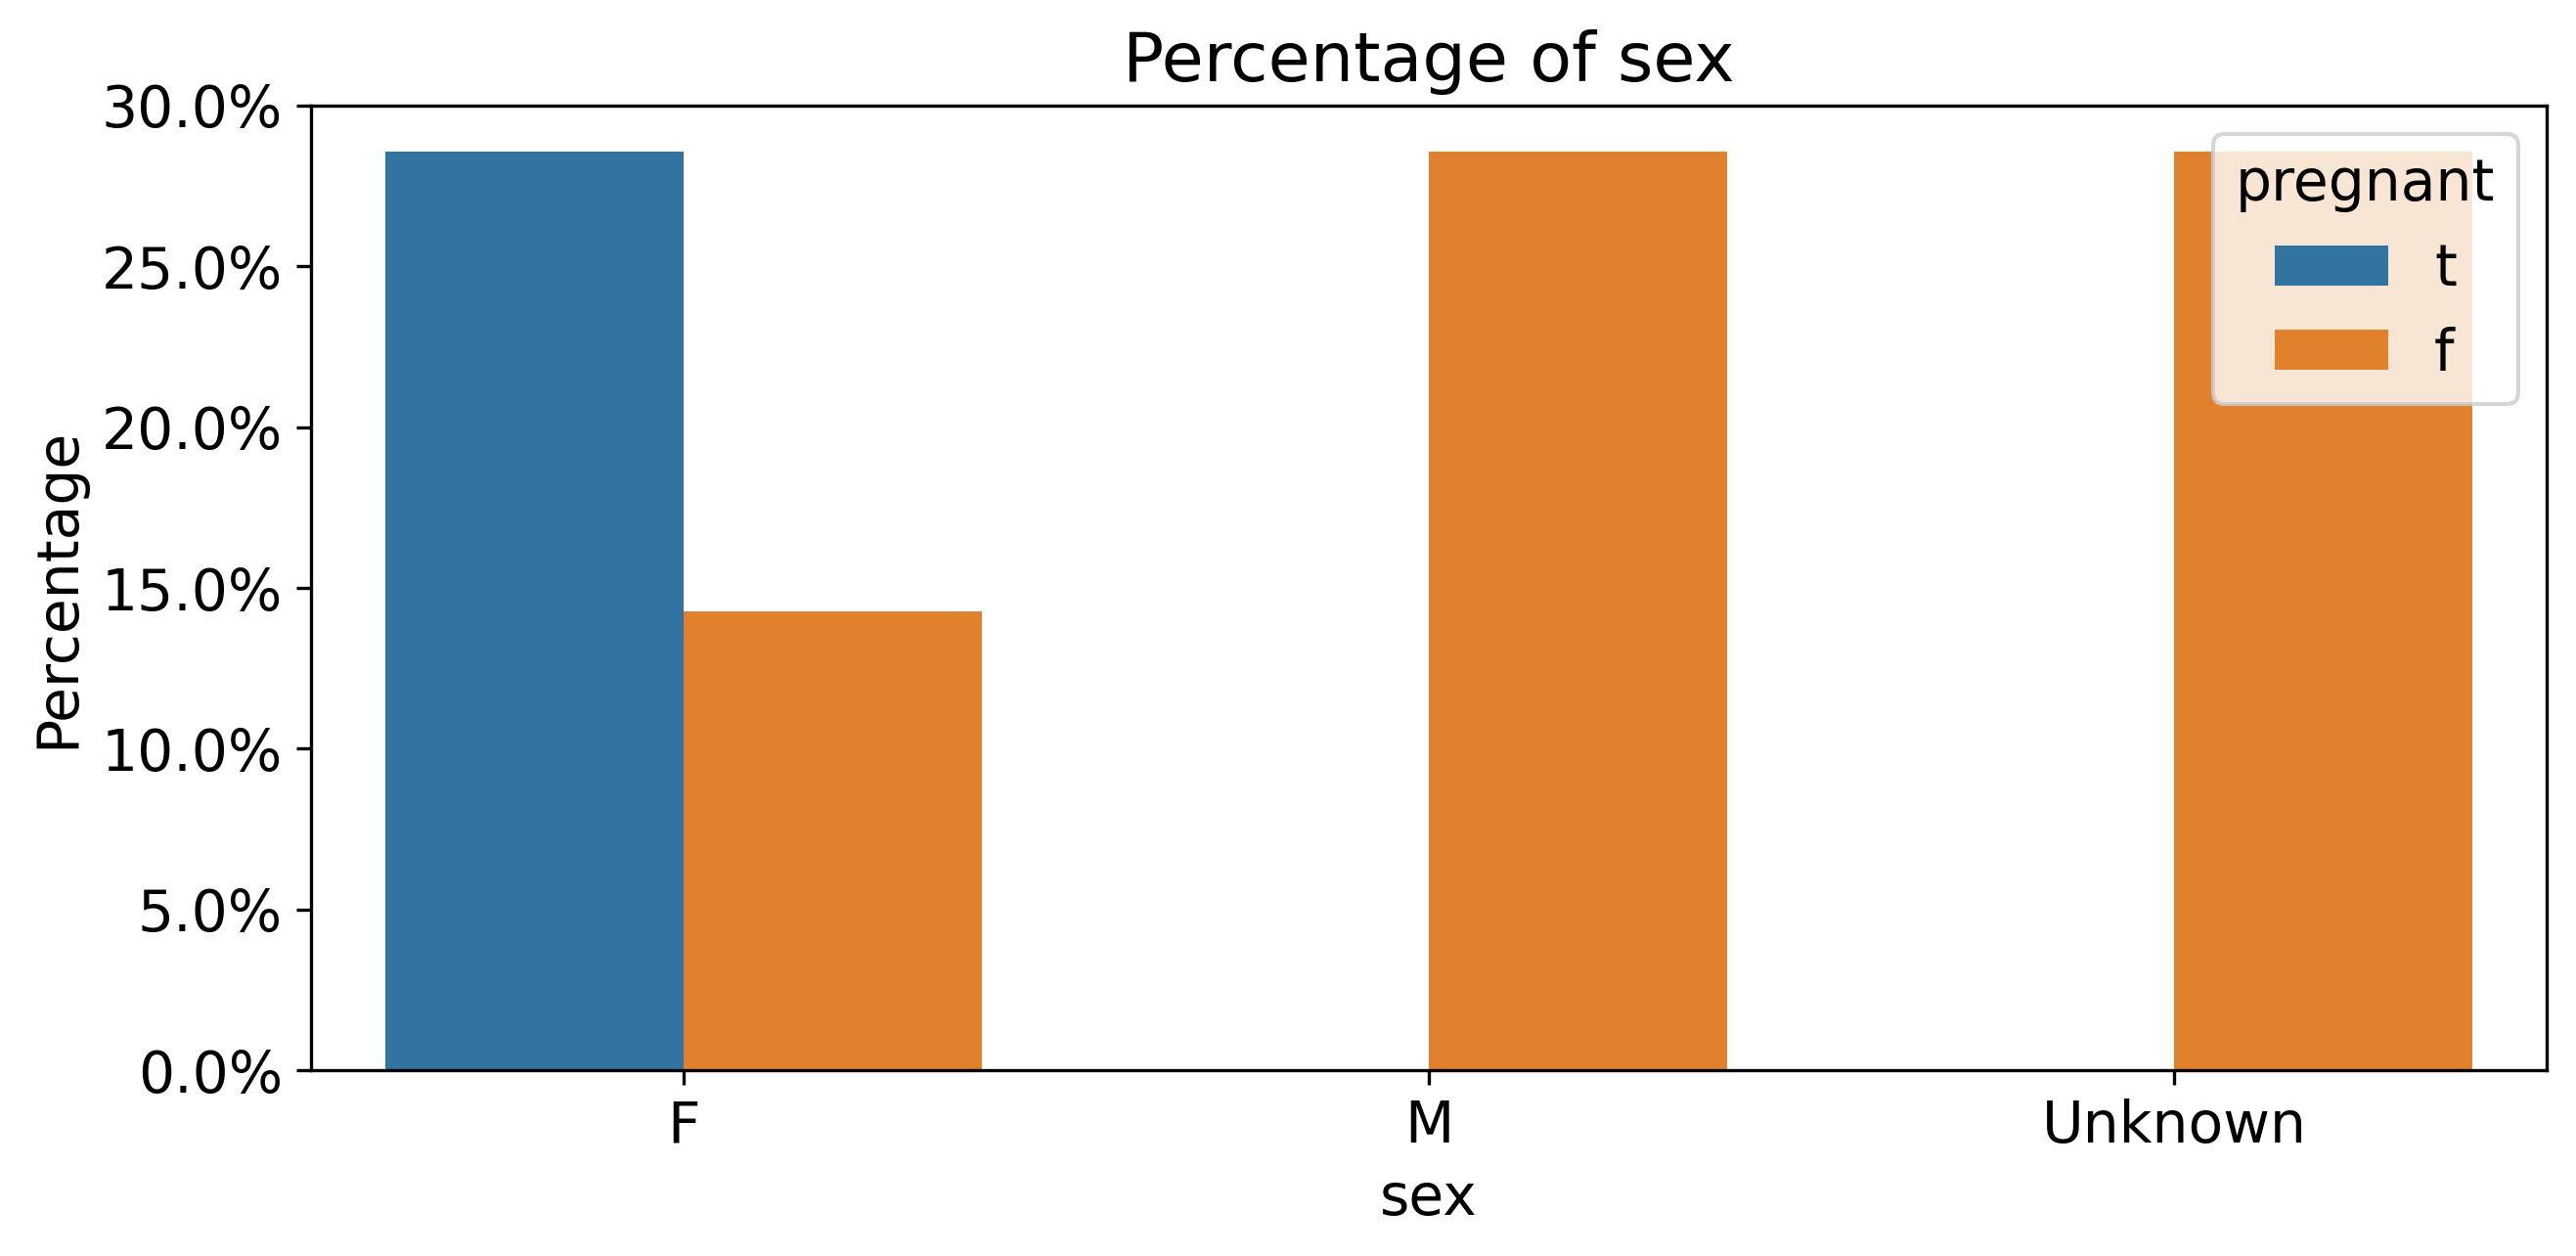

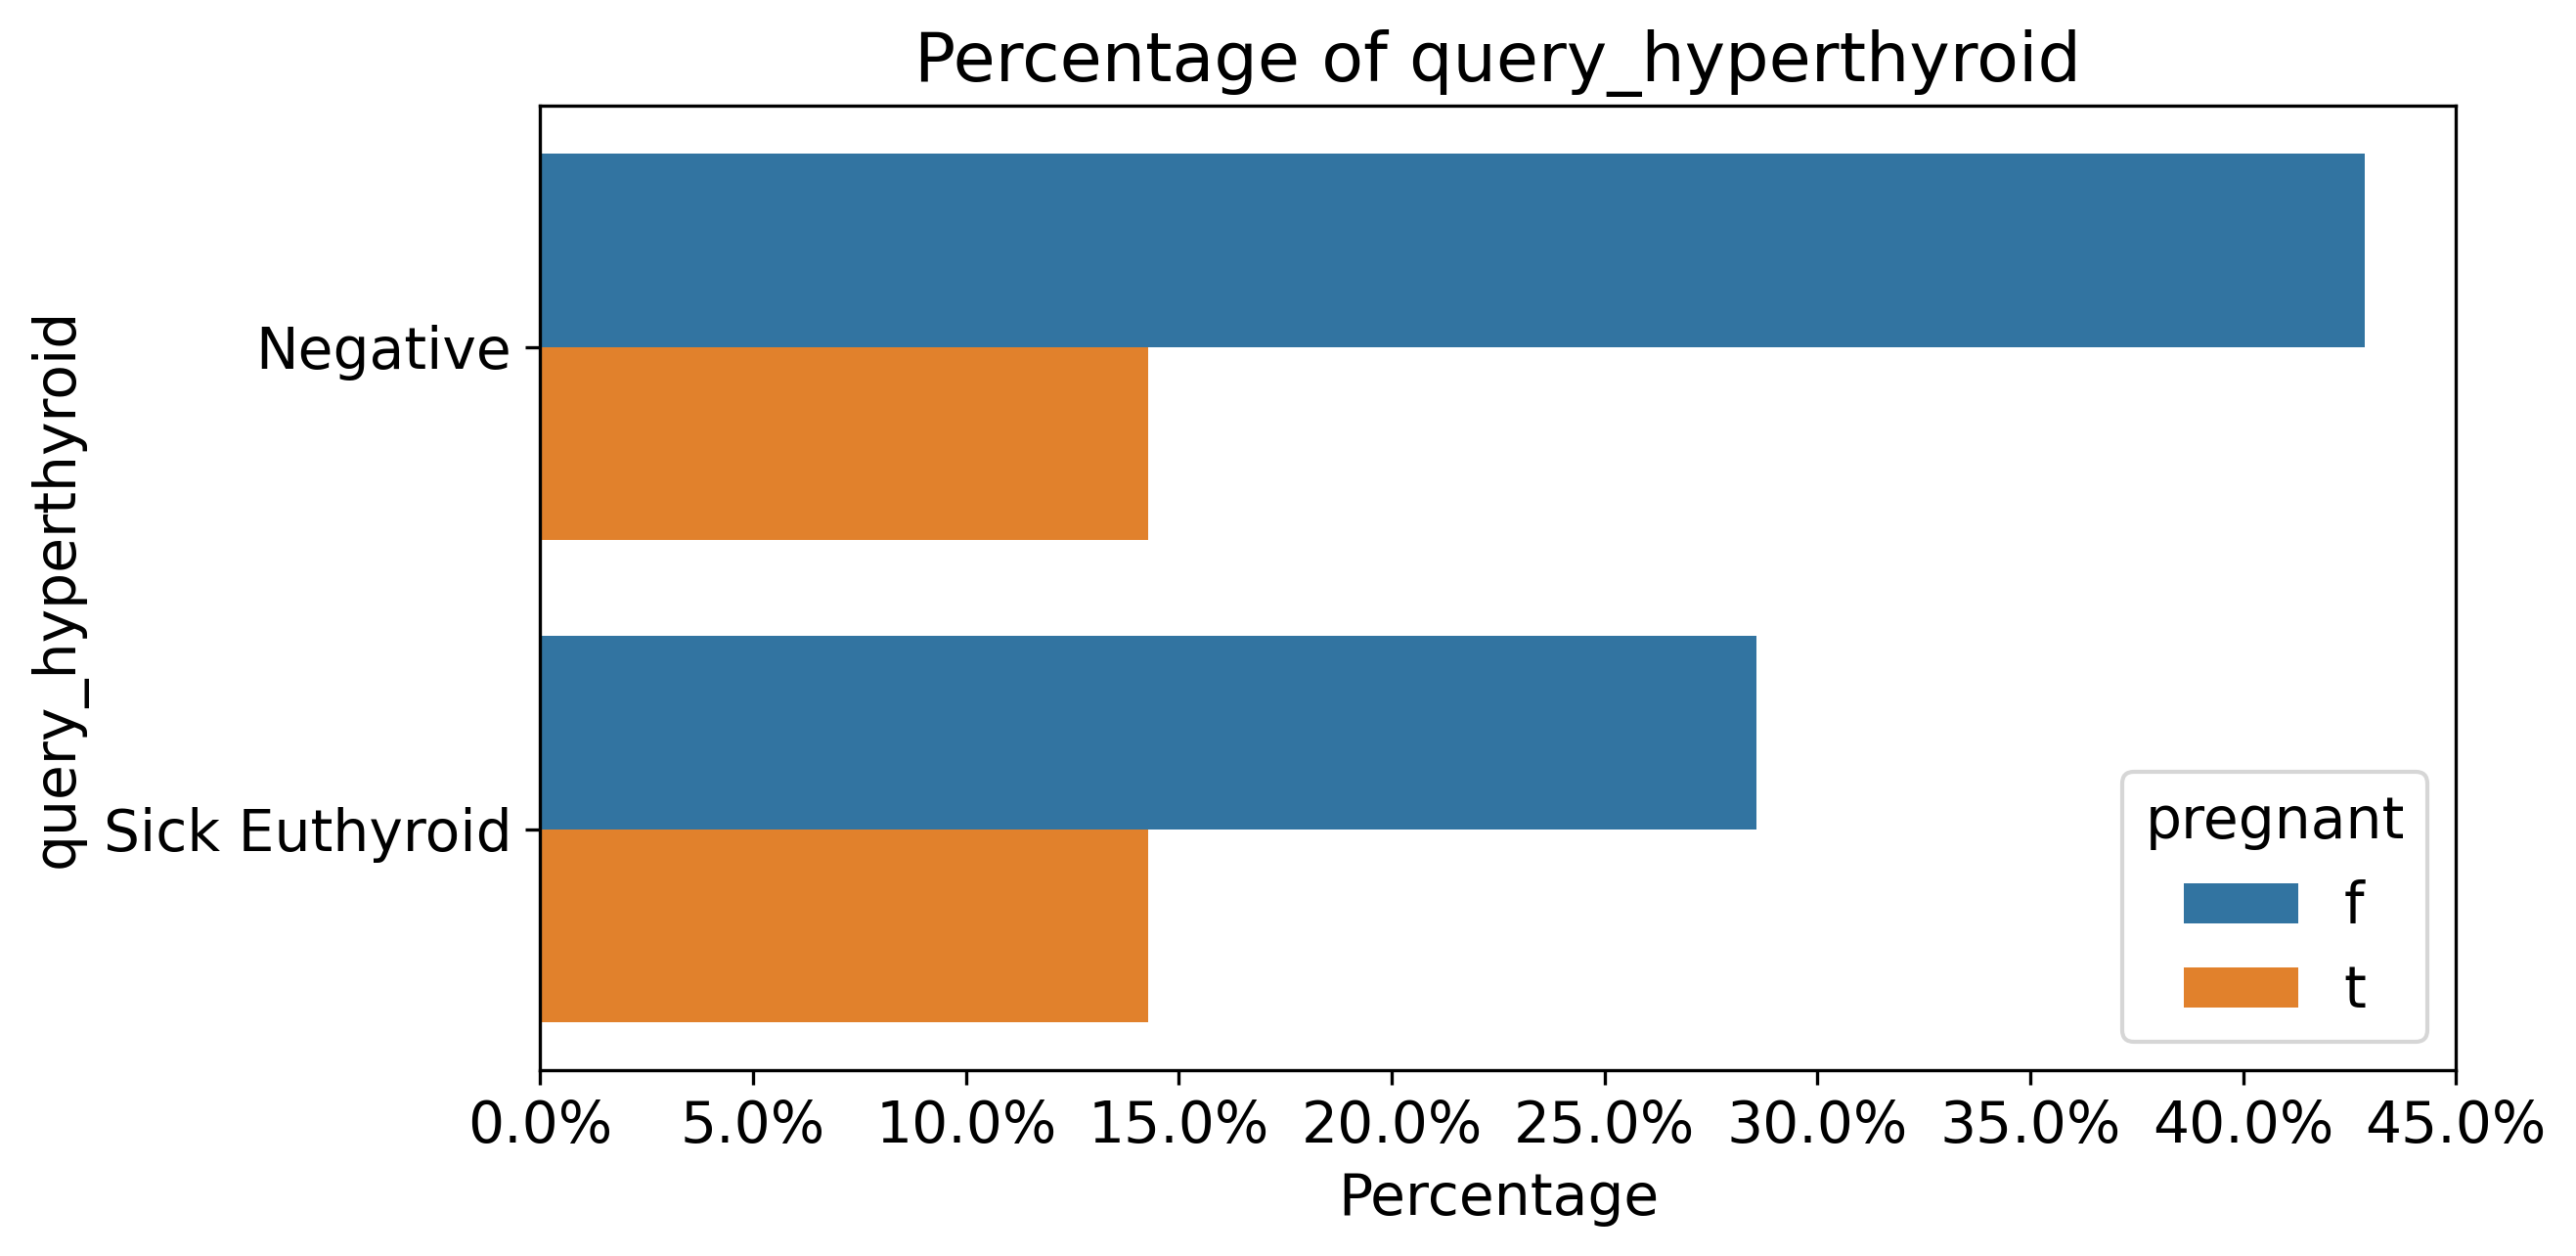

In [40]:
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd
from matplotlib.ticker import PercentFormatter

# Example: load your dataset
# data = pd.read_csv("your_file.csv")

# Dummy dataset for testing (remove if you load your own data)
data = pd.DataFrame({
    "sex": ["M", "F", "?", "M", "F", "F", "?"],
    "pregnant": ["f", "t", "f", "f", "t", "f", "f"],
    "query_hyperthyroid": ["f", "t", "f", "t", "f", "f", "t"]
})

# Replace missing values like '?' with 'Unknown'
if "sex" in data.columns:
    data["sex"] = data["sex"].replace("?", "Unknown")

# Replace query_hyperthyroid values for clarity
if "query_hyperthyroid" in data.columns:
    data["query_hyperthyroid"] = data["query_hyperthyroid"].replace({
        "f": "Negative",
        "t": "Sick Euthyroid"
    })

# ✅ Corrected function with orient argument
def barplot_percentages(feature, orient='v', axis_name="Percentage"):
    # Ensure feature and pregnant columns exist
    if feature not in data.columns or "pregnant" not in data.columns:
        raise ValueError(f"Columns '{feature}' or 'pregnant' not found in dataset")
    
    # Group and count pregnant values by feature
    g = data.groupby(feature)["pregnant"].value_counts().to_frame(name=axis_name).reset_index()
    
    # Calculate percentage of total dataset
    g[axis_name] = g[axis_name] / len(data)
    
    # Plot
    if orient == 'v':
        ax = sns.barplot(x=feature, y=axis_name, hue='pregnant', data=g, orient="v")
        ax.yaxis.set_major_formatter(PercentFormatter(1))
        ax.set_ylabel(axis_name)
    elif orient == 'h':
        ax = sns.barplot(x=axis_name, y=feature, hue='pregnant', data=g, orient="h")
        ax.xaxis.set_major_formatter(PercentFormatter(1))
        ax.set_xlabel(axis_name)
    else:
        raise ValueError("orient must be 'v' (vertical) or 'h' (horizontal)")
    
    plt.title(f"Percentage of {feature}")
    plt.tight_layout()
    plt.show()

# ✅ Example usage
plt.figure(figsize=(9, 4.5))
barplot_percentages("sex", orient='v')

plt.figure(figsize=(9, 4.5))
barplot_percentages("query_hyperthyroid", orient='h')


In [41]:
from sklearn.model_selection import train_test_split

target_col = "query_hyperthyroid"   # 👈 using this as target
feature_cols = ["sex", "pregnant"]  # 👈 features

x = data[feature_cols]
y = data[target_col]

X_train, X_test, y_train, y_test = train_test_split(x, y, test_size=0.30, random_state=42)


print("Train size:", X_train.shape, "Test size:", X_test.shape)


Train size: (4, 2) Test size: (3, 2)


In [42]:
print(data.columns)


Index(['sex', 'pregnant', 'query_hyperthyroid'], dtype='object')


In [43]:
classifiers = {
    "XGBClassifier" : XGBClassifier(learning_rate=0.01),
    "CatBoostClassifier" : CatBoostClassifier(max_depth=4,verbose=0)
}

In [ ]:
!pip install xgboost catboost


C:\Users\iamya\AppData\Roaming\Python\Python312\site-packages\xgboost\training.py:183: UserWarning: [20:28:08] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:738: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)



Confusion matrix for: XGBClassifier


,0,1
0,40,3
1,1,70


ROC AUC Score: 0.9895


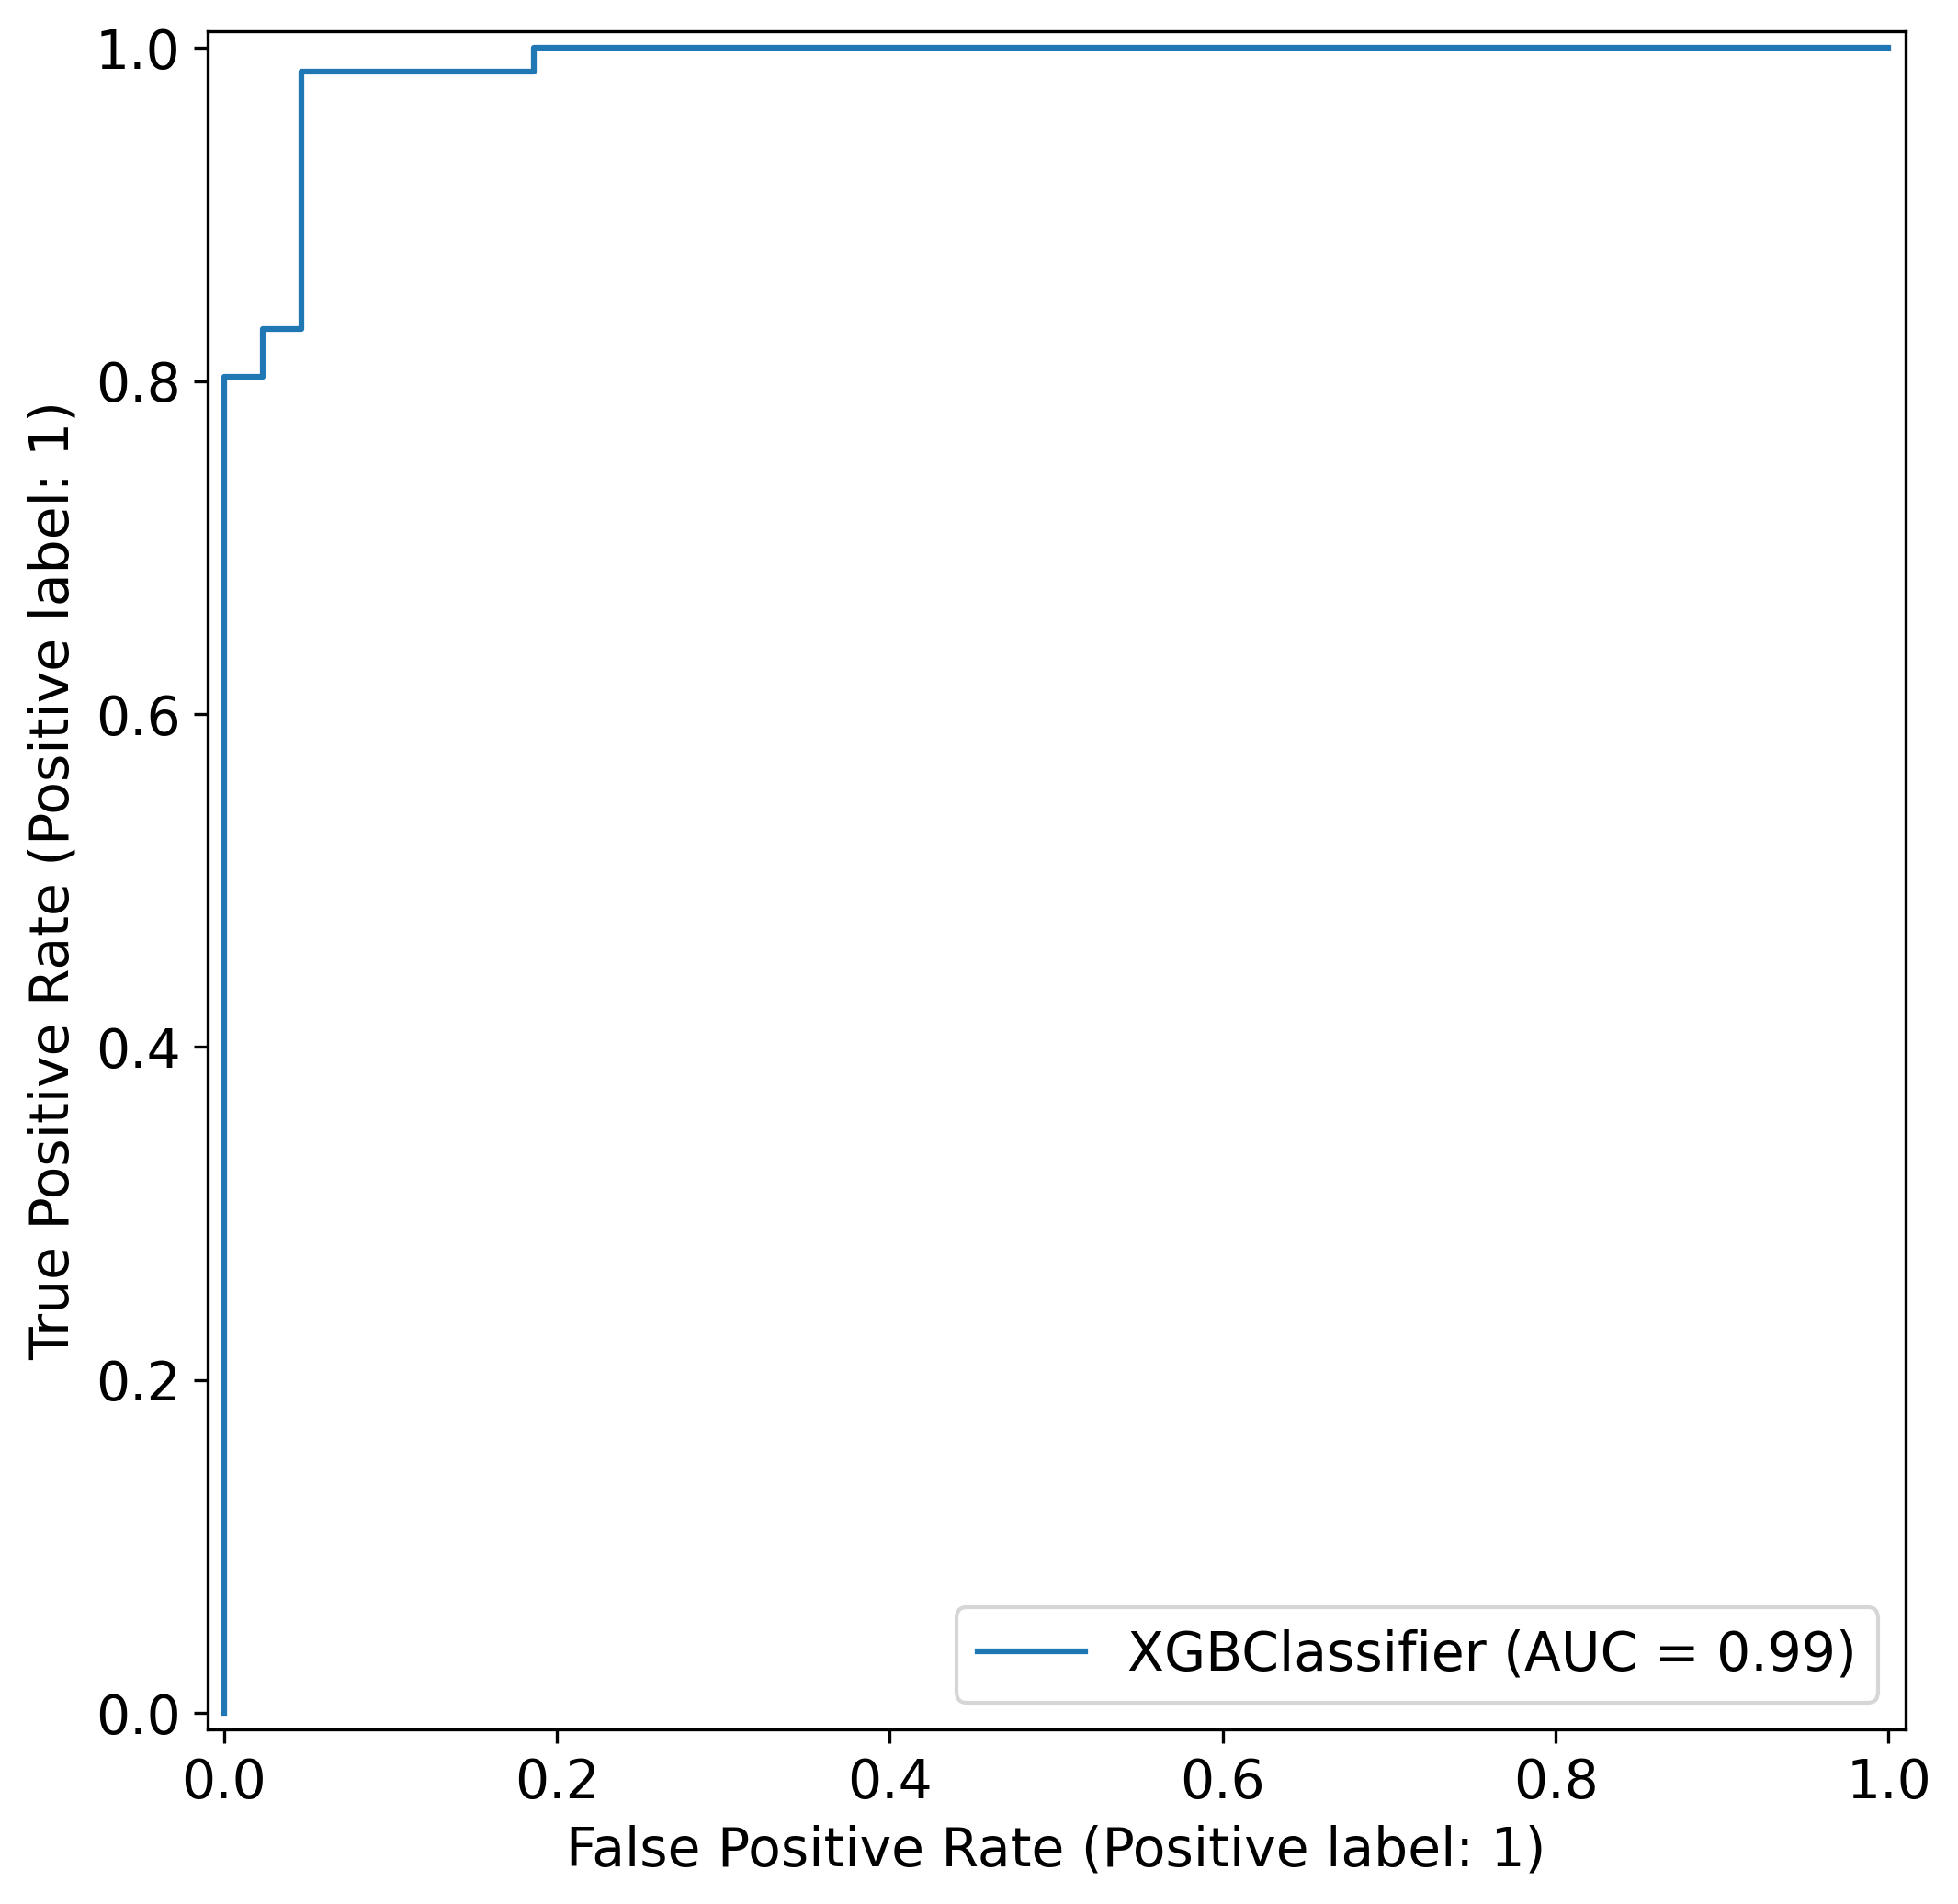


Confusion matrix for: CatBoostClassifier


,0,1
0,41,2
1,1,70


ROC AUC Score: 0.9967


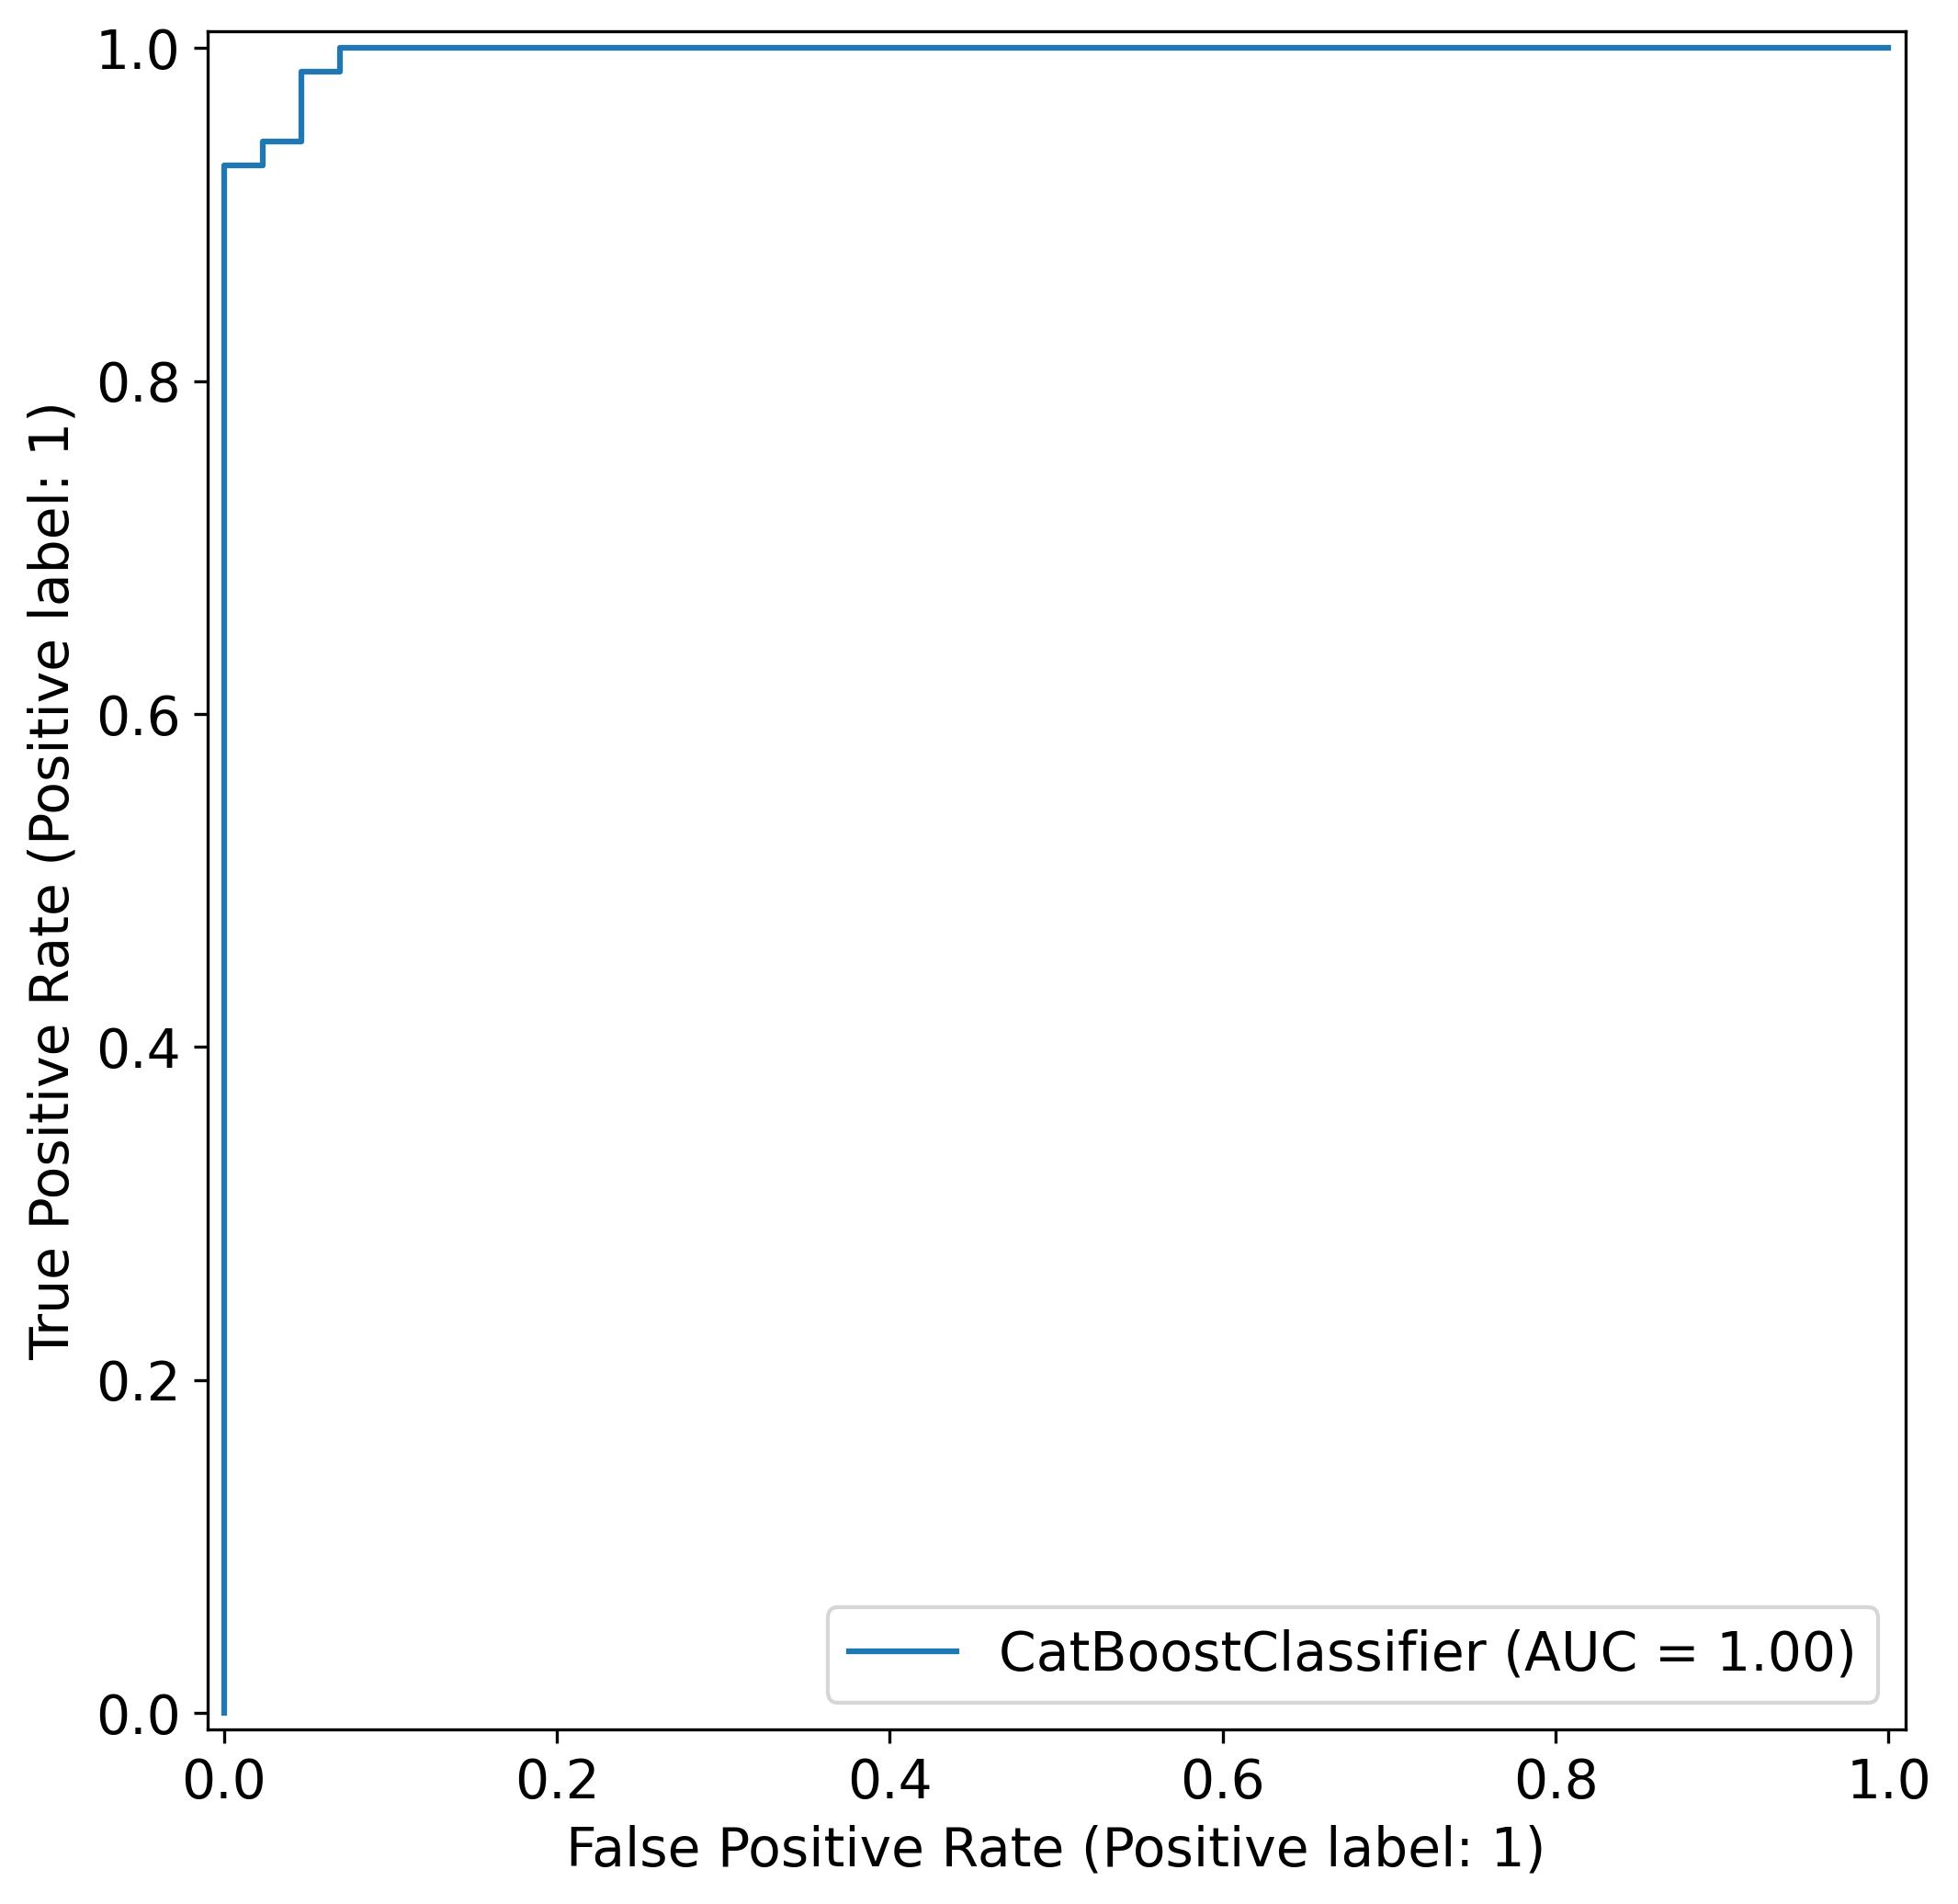


Confusion matrix for: RandomForest


,0,1
0,40,3
1,1,70


ROC AUC Score: 0.9953


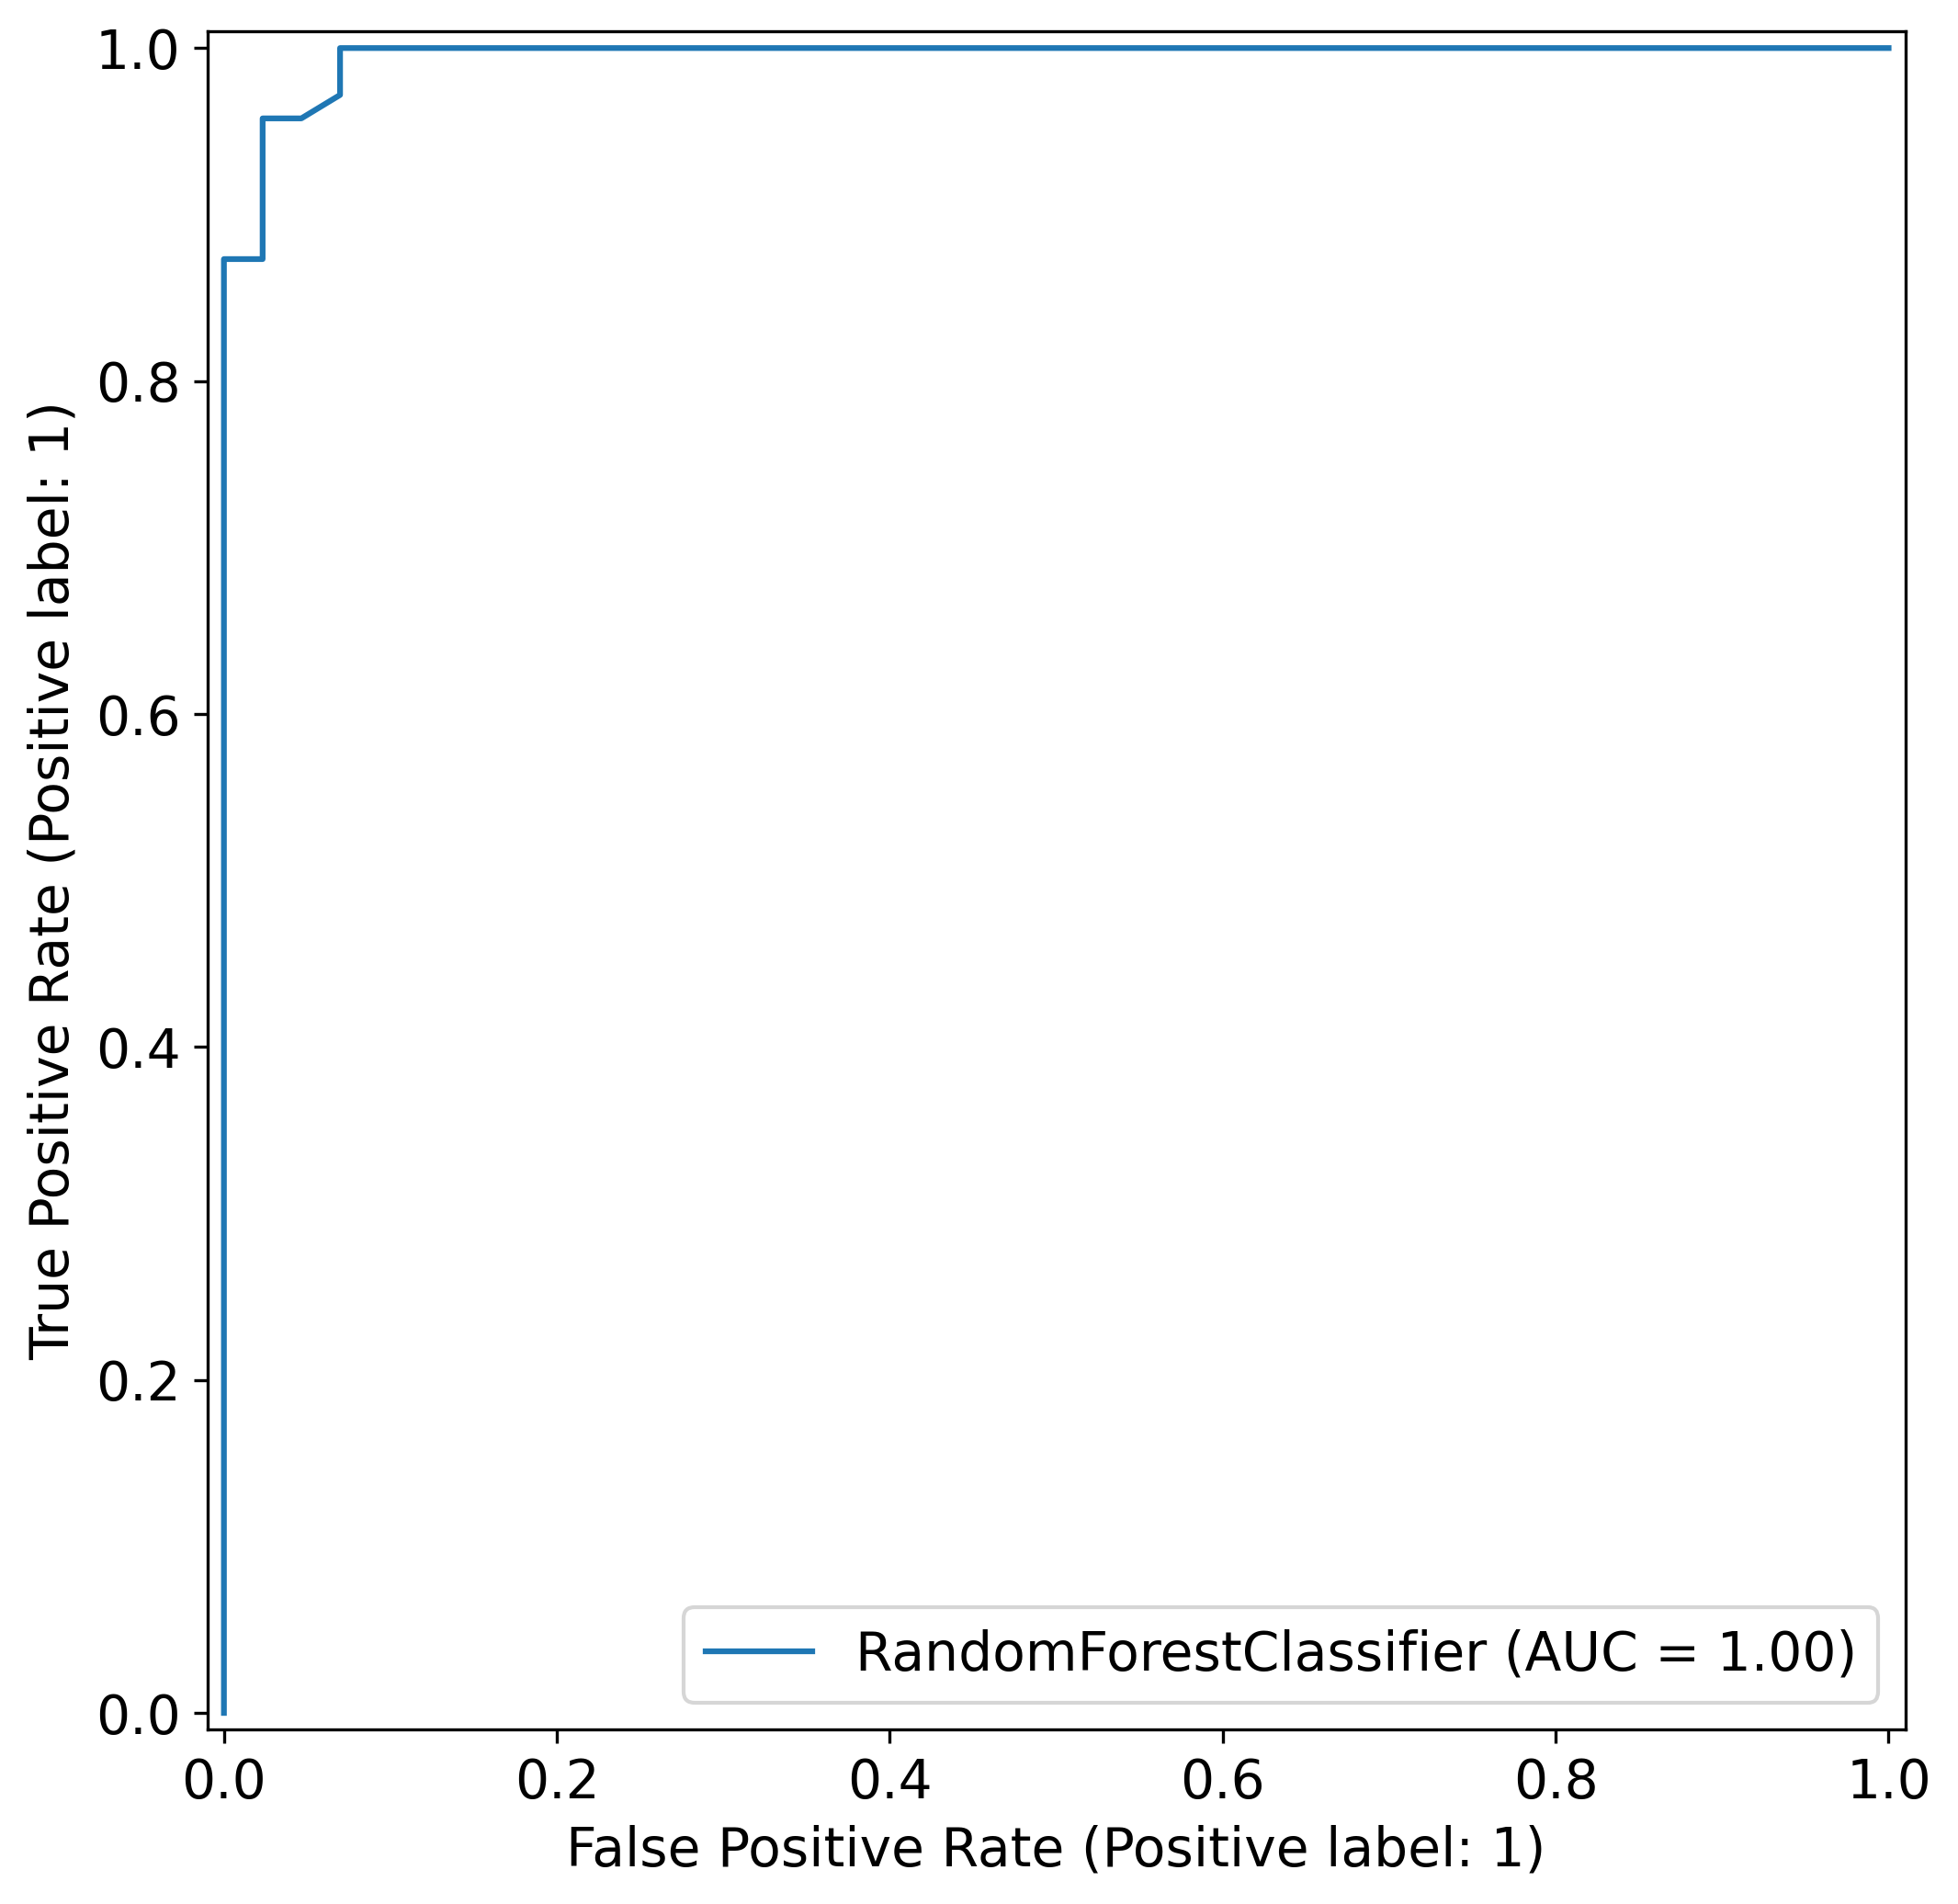


Confusion matrix for: LogisticRegression


C:\Users\iamya\anaconda3\Lib\site-packages\sklearn\linear_model\_logistic.py:473: ConvergenceWarning: lbfgs failed to converge after 1000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=1000).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


,0,1
0,39,4
1,1,70


ROC AUC Score: 0.9977


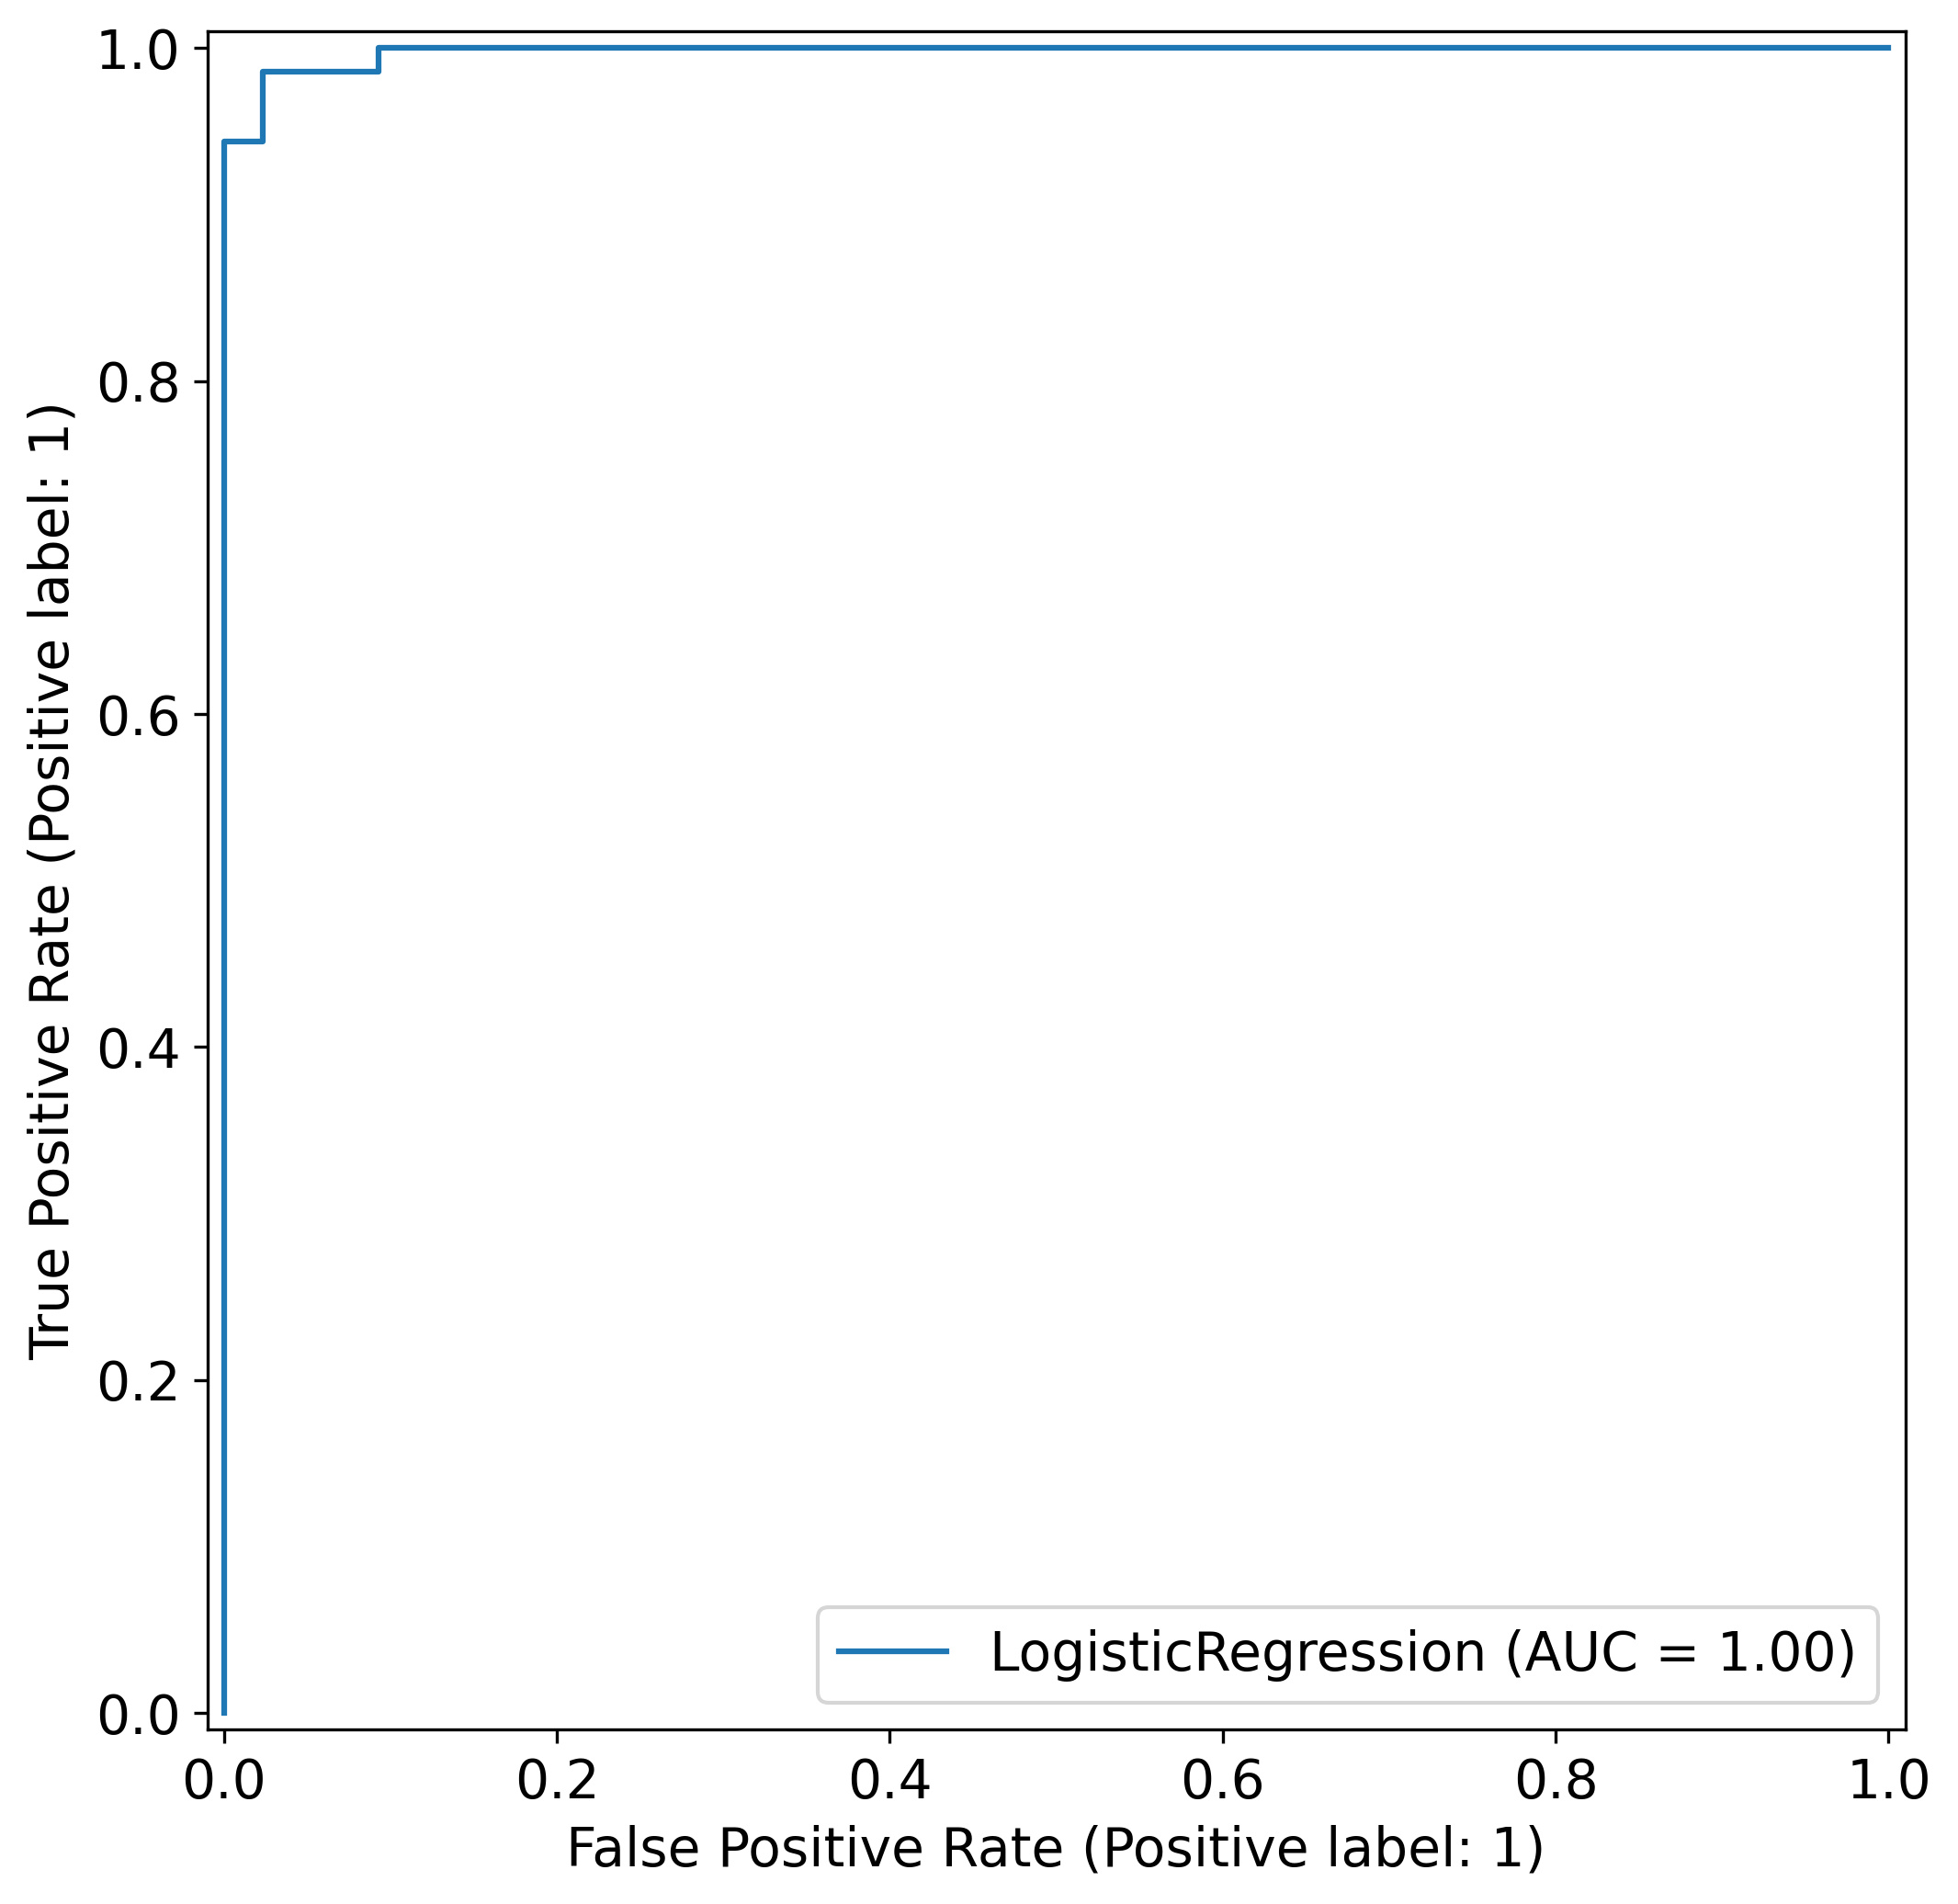


Confusion matrix for: SVC


,0,1
0,37,6
1,0,71


ROC AUC Score: 0.9934


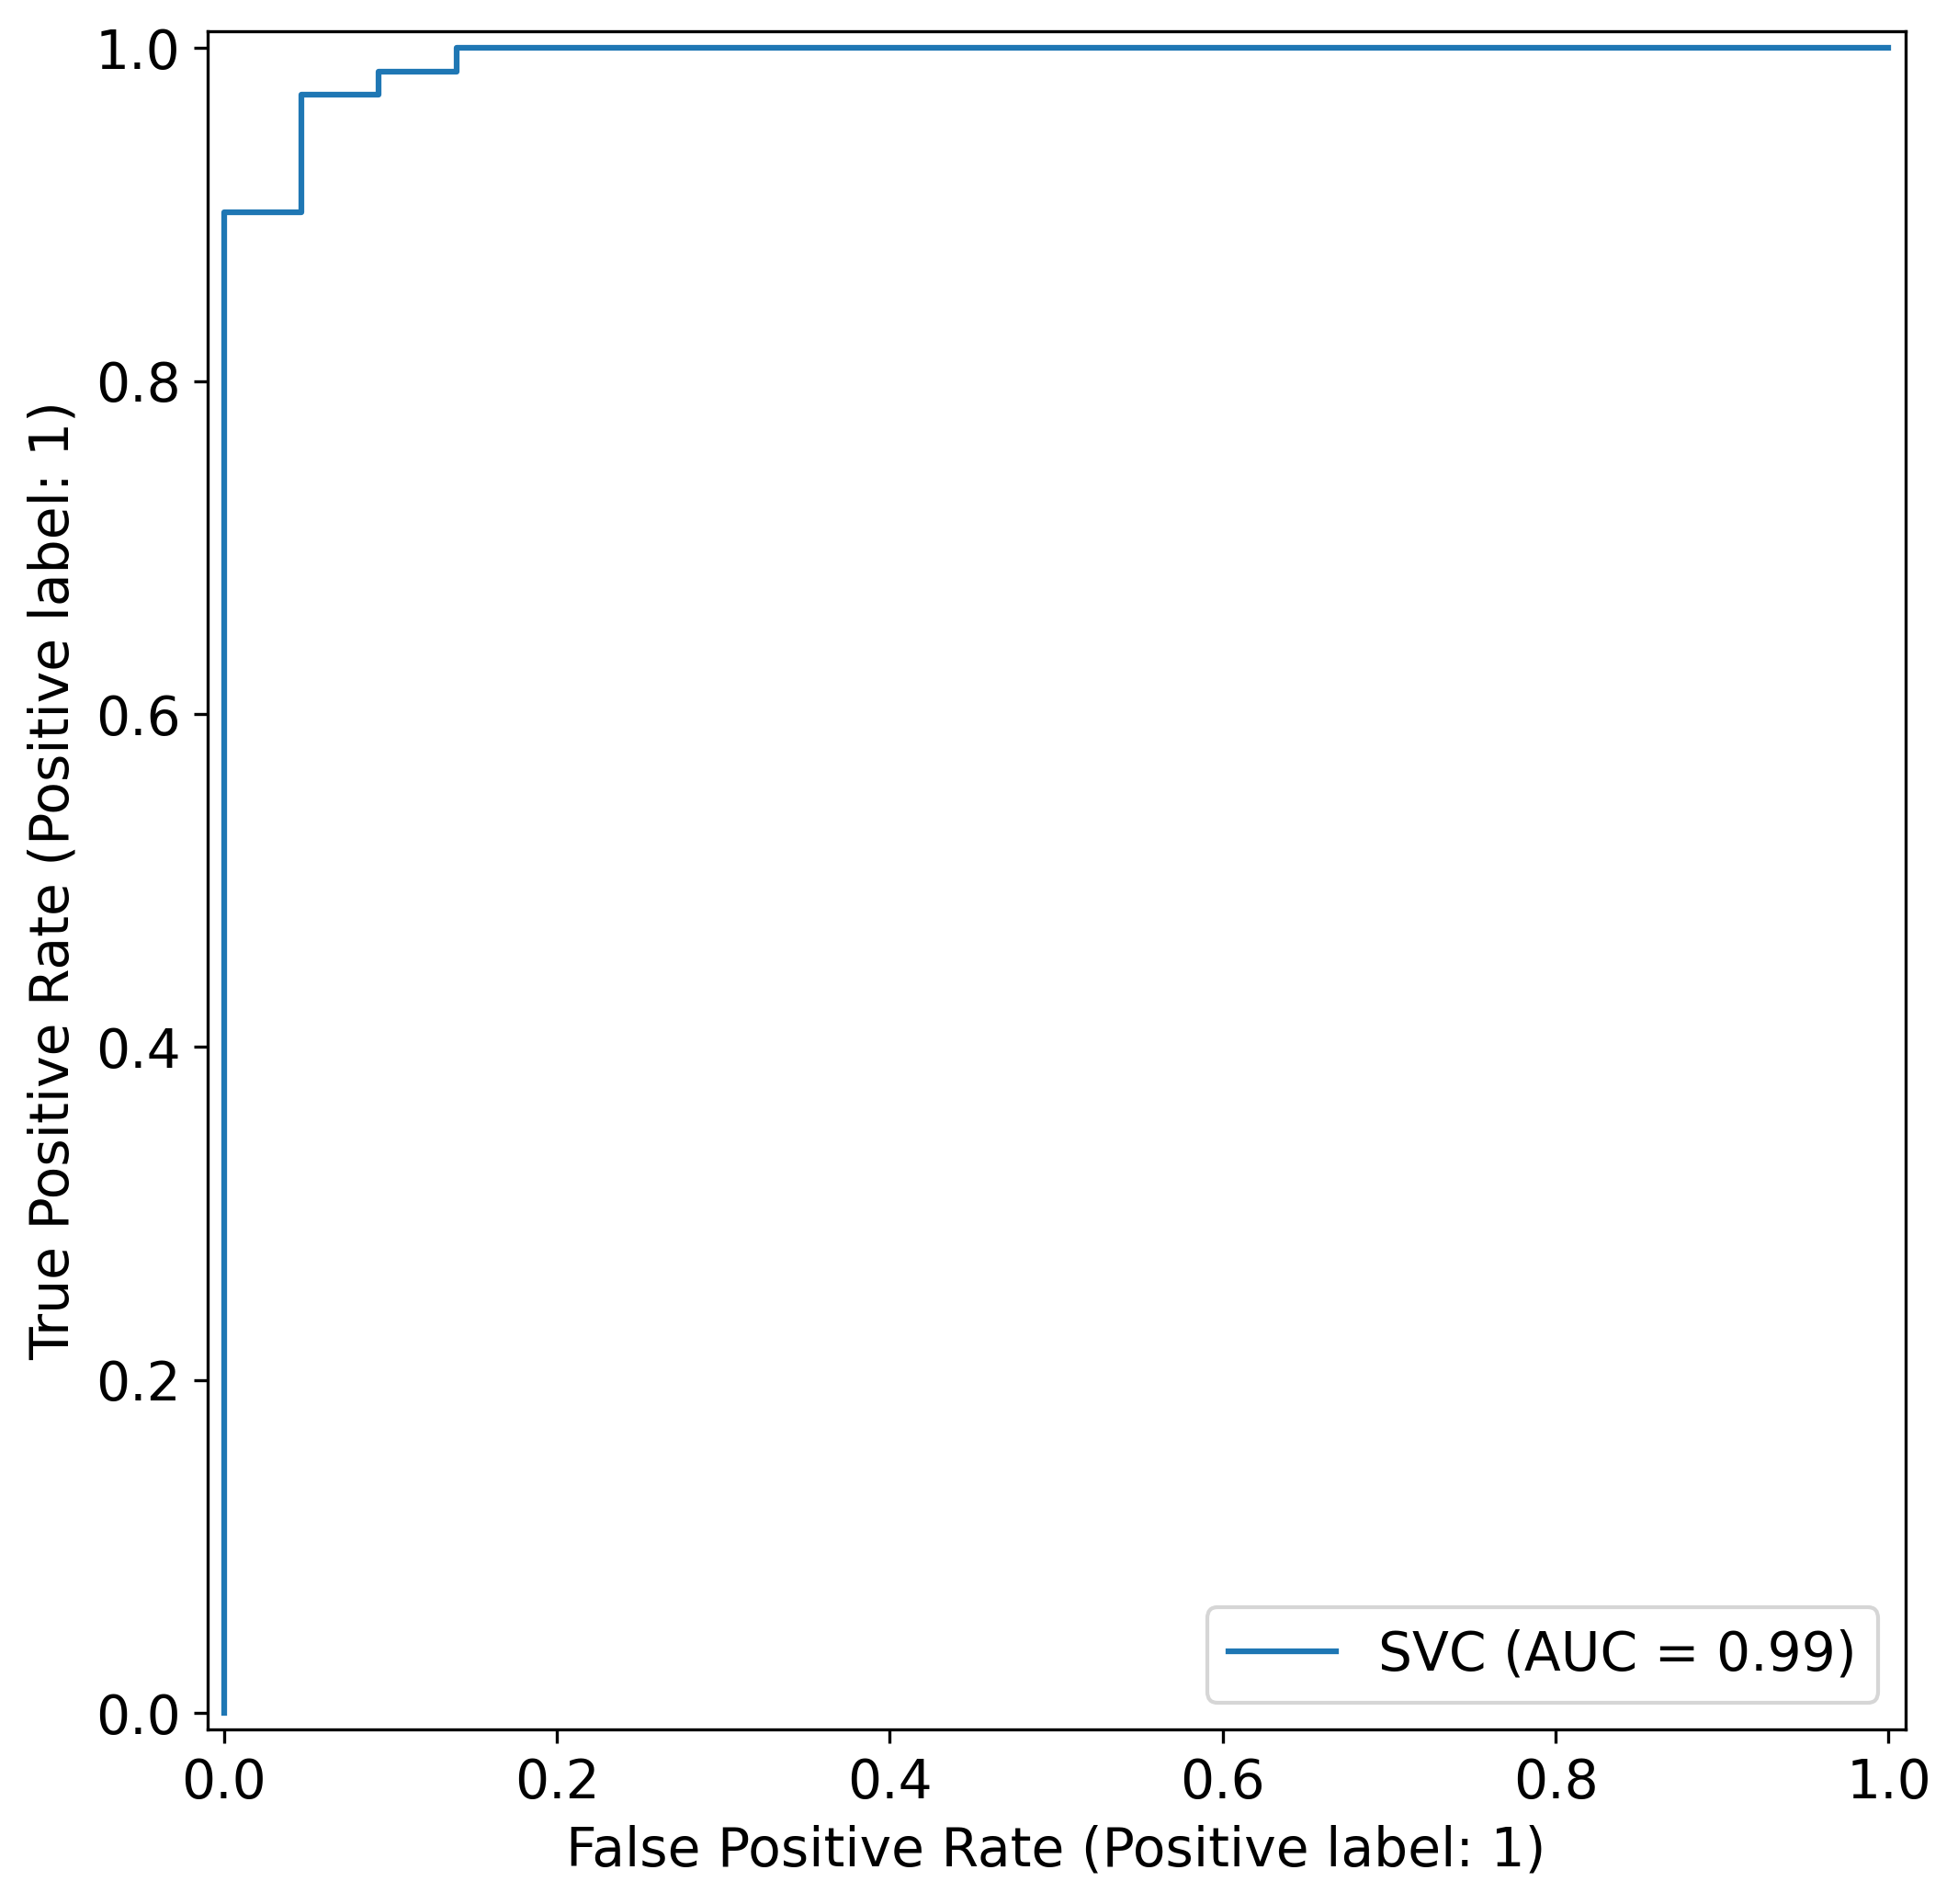

,Accuracy,Precision,Recall,FScore
Classifier,,,,
CatBoostClassifier,0.9737,0.9742,0.9697,0.9719
XGBClassifier,0.9649,0.9673,0.9581,0.9623
RandomForest,0.9649,0.9673,0.9581,0.9623
LogisticRegression,0.9561,0.9605,0.9464,0.9526
SVC,0.9474,0.9610,0.9302,0.9422


In [44]:
# Install libraries if not already installed (uncomment if needed)
# !pip install xgboost catboost

import matplotlib.pyplot as plt
import pandas as pd
from sklearn import metrics
from sklearn.metrics import confusion_matrix, roc_auc_score, RocCurveDisplay
from sklearn.model_selection import train_test_split
from sklearn.datasets import load_breast_cancer

# Classifiers
from xgboost import XGBClassifier
from catboost import CatBoostClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC

# --------------------------------------------------------
# Define classifiers dictionary
classifiers = {
    "XGBClassifier": XGBClassifier(learning_rate=0.01, use_label_encoder=False, eval_metric='logloss'),
    "CatBoostClassifier": CatBoostClassifier(max_depth=4, verbose=0),
    "RandomForest": RandomForestClassifier(n_estimators=100, random_state=42),
    "LogisticRegression": LogisticRegression(max_iter=1000),
    "SVC": SVC(probability=True, random_state=42)  # enable probability=True for ROC curve
}

# --------------------------------------------------------
# Classification function
def classification(classifiers, X_train, X_test, y_train, y_test):
    res = pd.DataFrame(columns=["Classifier", "Accuracy", "Precision", "Recall", "FScore"])

    for name, clf in classifiers.items():
        clf.fit(X_train, y_train)
        y_pred = clf.predict(X_test)

        pr, rc, fs, _ = metrics.precision_recall_fscore_support(y_test, y_pred, average='macro')

        # add results row
        res.loc[len(res)] = {
            "Classifier": name,
            "Accuracy": round(metrics.accuracy_score(y_test, y_pred), 4),
            "Precision": round(pr, 4),
            "Recall": round(rc, 4),
            "FScore": round(fs, 4)
        }

        print("\nConfusion matrix for:", name)
        display(pd.DataFrame(confusion_matrix(y_test, y_pred)))

        # ROC curve
        if hasattr(clf, "predict_proba"):
            y_score = clf.predict_proba(X_test)[:, 1]
            print('ROC AUC Score:', round(roc_auc_score(y_test, y_score), 4))
            RocCurveDisplay.from_estimator(clf, X_test, y_test)
            plt.show()
        elif hasattr(clf, "decision_function"):
            y_score = clf.decision_function(X_test)
            print('ROC AUC Score:', round(roc_auc_score(y_test, y_score), 4))
            RocCurveDisplay.from_estimator(clf, X_test, y_test)
            plt.show()
        else:
            print("ROC curve not available for", name)

    res.set_index("Classifier", inplace=True)
    res.sort_values(by="FScore", ascending=False, inplace=True)
    return res

# --------------------------------------------------------
# Load dataset and split
data = load_breast_cancer()
X, y = data.data, data.target
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# --------------------------------------------------------
# Run evaluation
results = classification(classifiers, X_train, X_test, y_train, y_test)
display(results)

# Optionally save results to CSV
results.to_csv("classification_results.csv", index=True)
